# RFM CUSTOMER SEGMENTATION
BankTrust's Aims from this project:
- Customer Churn (Reduction of number of cutomers that churn)
- Personalisation (Improve on personalising each customer's experience with the bank)
- Marketing Efficiency (Aim to increase the marketing efficiency)

How to achieve this:
- Using RFM analysis, a data-driven technique used to segment customers based on their past behaviours.

Tools:

&#x1F4BB; Terminal, Git, VS Code, Jupyter Notebook

&#x1F40D; Python

&#x1F4DA; Libraries: pandas, numpy, matplotlib, seaborn, scikit-learn, streamlit

## 📦 LIBRARY INSTALLATION AND IMPORTATION

In [1]:
!pip install pandas numpy seaborn matplotlib lifetimes scikit-learn yellowbrick -q


[notice] A new release of pip is available: 24.0 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
import sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import yellowbrick
from yellowbrick.cluster import KElbowVisualizer
from sklearn.decomposition import PCA

#setting display settings for the plots.
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

## 📂 DATA LOADING AND EXPLORATION.

In [3]:
df = pd.read_csv('dataset/banktrust_data.csv') #reading in the data.

df.info() #displaying information about the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041614 entries, 0 to 1041613
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1041614 non-null  object 
 1   CustomerID               1041614 non-null  object 
 2   CustomerDOB              1041614 non-null  object 
 3   CustGender               1041614 non-null  object 
 4   CustLocation             1041614 non-null  object 
 5   CustAccountBalance       1041614 non-null  float64
 6   TransactionDate          1041614 non-null  object 
 7   TransactionTime          1041614 non-null  int64  
 8   TransactionAmount (INR)  1041614 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 71.5+ MB


In [4]:
df.head() #displaying the first five rows of data.

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [5]:
df.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.041614e+06,1.041614e+06,1.041614e+06
mean,1.149986e+05,1.571221e+05,1.566096e+03
std,8.467609e+05,5.126352e+04,6.561464e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.728140e+03,1.240410e+05,1.600000e+02
50%,1.676852e+04,1.642470e+05,4.575000e+02
75%,5.742885e+04,2.000220e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


In [6]:
#checking data structure

df.shape

(1041614, 9)

## 🧹 DATA CLEANING.

In [7]:
#checking for null values in the dataset.
df.isna().sum()

TransactionID              0
CustomerID                 0
CustomerDOB                0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
dtype: int64

_No null values._

In [8]:
#converting dates and times.
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], dayfirst=True) #dayfirst=True ensures that dates are not mistaken for American format.
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, format='%d/%m/%y')

df.head() #viewing the data

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5


In [9]:
df['TransactionDate'].unique()

<DatetimeArray>
['2016-08-02 00:00:00', '2016-08-01 00:00:00', '2016-08-03 00:00:00',
 '2016-08-05 00:00:00', '2016-08-04 00:00:00', '2016-08-06 00:00:00',
 '2016-08-09 00:00:00', '2016-08-08 00:00:00', '2016-08-12 00:00:00',
 '2016-08-07 00:00:00', '2016-10-21 00:00:00', '2016-10-16 00:00:00',
 '2016-08-10 00:00:00', '2016-08-14 00:00:00', '2016-08-17 00:00:00',
 '2016-08-21 00:00:00', '2016-08-19 00:00:00', '2016-08-24 00:00:00',
 '2016-08-22 00:00:00', '2016-08-29 00:00:00', '2016-08-31 00:00:00',
 '2016-09-22 00:00:00', '2016-09-23 00:00:00', '2016-08-13 00:00:00',
 '2016-08-25 00:00:00', '2016-08-28 00:00:00', '2016-08-15 00:00:00',
 '2016-08-27 00:00:00', '2016-08-20 00:00:00', '2016-08-23 00:00:00',
 '2016-08-30 00:00:00', '2016-08-11 00:00:00', '2016-08-16 00:00:00',
 '2016-08-26 00:00:00', '2016-09-27 00:00:00', '2016-08-18 00:00:00',
 '2016-09-25 00:00:00', '2016-09-26 00:00:00', '2016-09-30 00:00:00',
 '2016-09-03 00:00:00', '2016-09-02 00:00:00', '2016-09-01 00:00:00',
 '20

### _AGE._
Calulcating the customer's age at the time of the transaction. Subtracting their date of birth from the transaction date.

In [10]:
def calculate_age(df):
    df['Age'] = (df['TransactionDate'] - df['CustomerDOB']).dt.days // 365
    return df

calculate_age(df) #calling the function
df.head(5)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,22
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,-41
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,19
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,-58
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,28


##### &#x1F4A5;	Issue with date of birth column has been observed, as some ages are negative. Viewing these specific ages.

In [11]:
#viewing the rows with negative ages.
print(df[df['Age'] <= 0]['CustomerDOB'])

print(f"The number of rows with negative ages is {len(df[df['Age'] <= 0]['CustomerDOB'])}")

1         2057-04-04
3         2073-09-14
5         2072-10-08
15        2068-07-10
29        2067-01-21
             ...    
1041553   2070-09-20
1041557   2048-07-15
1041583   2033-10-05
1041591   2071-10-05
1041599   2071-08-21
Name: CustomerDOB, Length: 104840, dtype: datetime64[ns]
The number of rows with negative ages is 104840


In [12]:
negative_ages = df[df['Age'] < 0] #viewing these rows, to see if there's anything special we can notice

negative_ages

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.00,-41
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.00,-58
5,T6,C1536588,2072-10-08,F,ITANAGAR,53609.20,2016-08-02,173940,676.00,-57
15,T16,C8334633,2068-07-10,F,NEW DELHI,1283.12,2016-08-01,125725,250.00,-52
29,T31,C7648712,2067-01-21,F,NEW DELHI,298461.05,2016-08-03,160642,500.00,-51
...,...,...,...,...,...,...,...,...,...,...
1041553,T1048507,C3333984,2070-09-20,M,NAVI MUMBAI,41.82,2016-09-18,182310,878.18,-55
1041557,T1048511,C3429427,2048-07-15,M,HOWRAH,416244.74,2016-09-18,184959,1695.00,-32
1041583,T1048537,C2939947,2033-10-05,M,NEW DELHI,92173.35,2016-09-18,184556,1319.04,-18
1041591,T1048545,C3712582,2071-10-05,M,MUMBAI,25414.52,2016-09-18,182015,400.00,-56


&#x1F441; No pattern can be noticed in the other columns of the rows. Also, looking at the figures for the DOB years, it looks like "20" should be "19", but this is an assumption that can't be jumped into, so a smarter way to input the ages may need to be thought of. Attempting to fix this, rather than drop all the rows. To decide, let's visualize the ages and do further anaylis of the dataset.

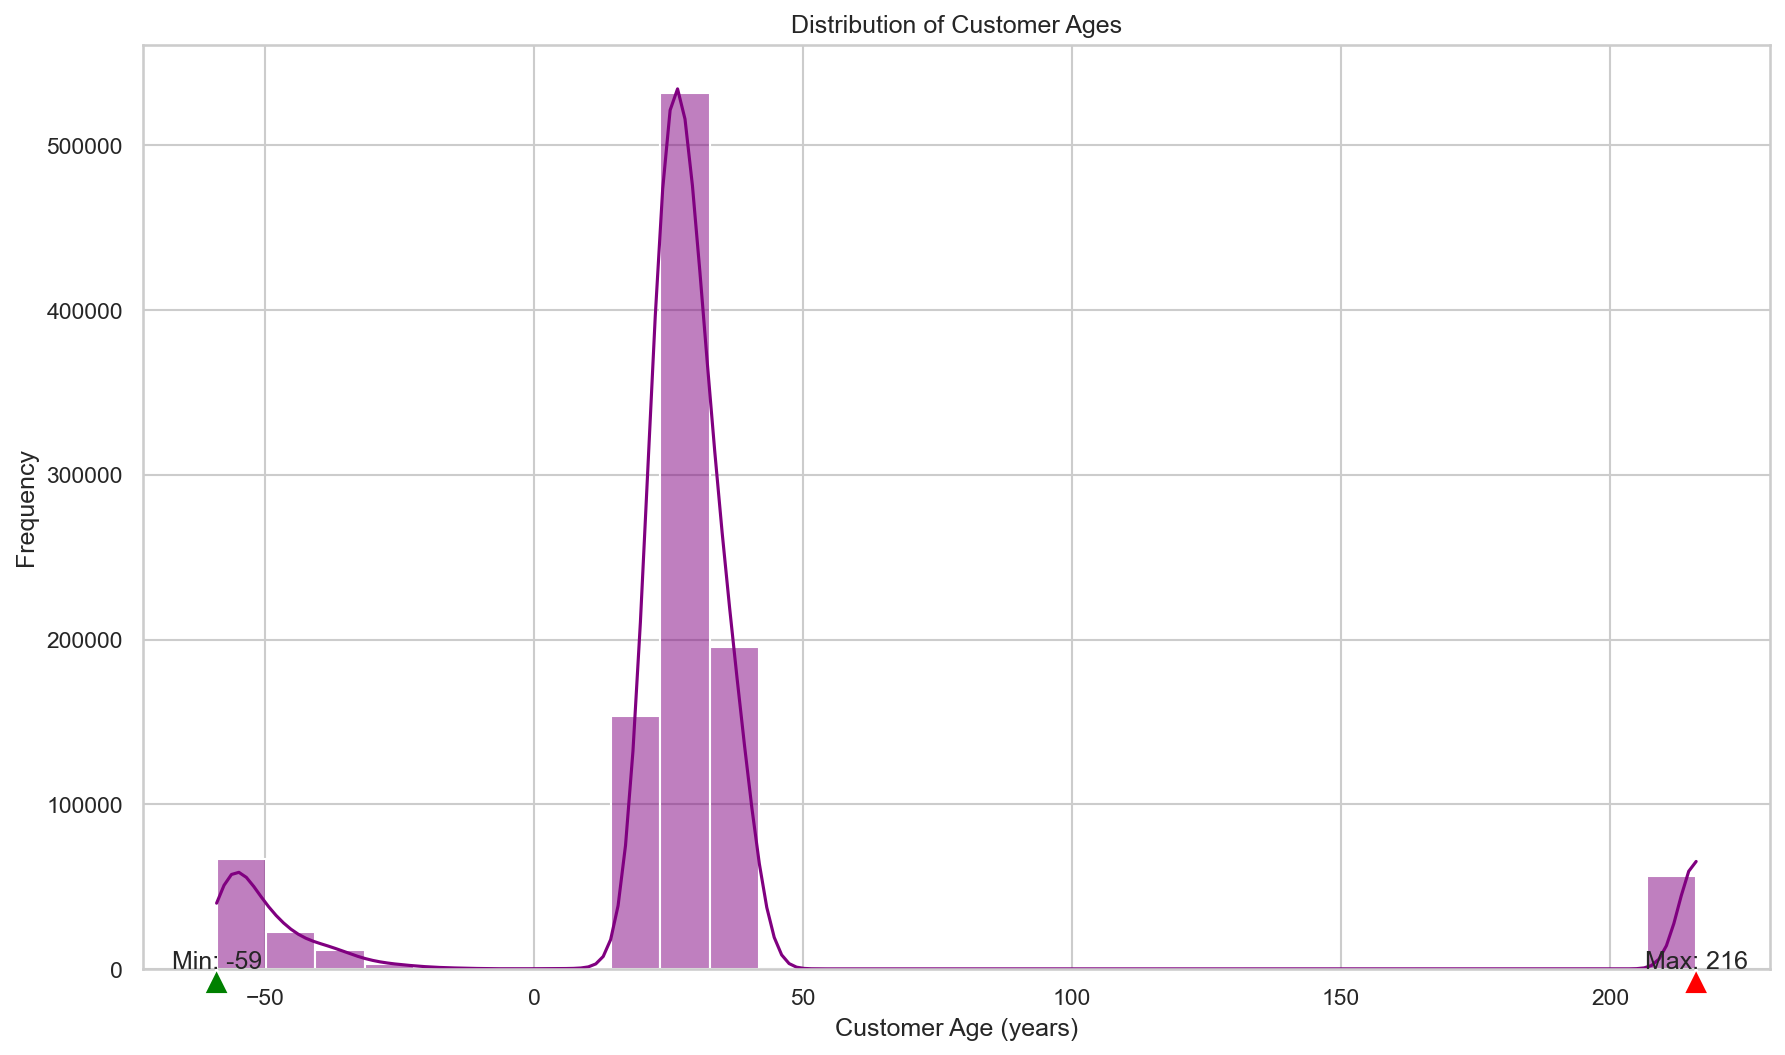

In [13]:
plt.figure(dpi=150) #so the plot is sharp/clear.

#to find min and max ages
min_age = df['Age'].min()
max_age = df['Age'].max()

#plotting the histogram with KDE
sns.histplot(df['Age'], bins=30, kde=True, color='purple')
plt.title('Distribution of Customer Ages')
plt.xlabel('Customer Age (years)')
plt.ylabel('Frequency')

#annotating min and max on x-axis
plt.annotate(f'Min: {min_age}', xy=(min_age, 0), xytext=(min_age, 5),
             arrowprops=dict(facecolor='green', shrink=0.05),
             ha='center')

plt.annotate(f'Max: {max_age}', xy=(max_age, 0), xytext=(max_age, 5),
             arrowprops=dict(facecolor='red', shrink=0.05),
             ha='center')

plt.show()

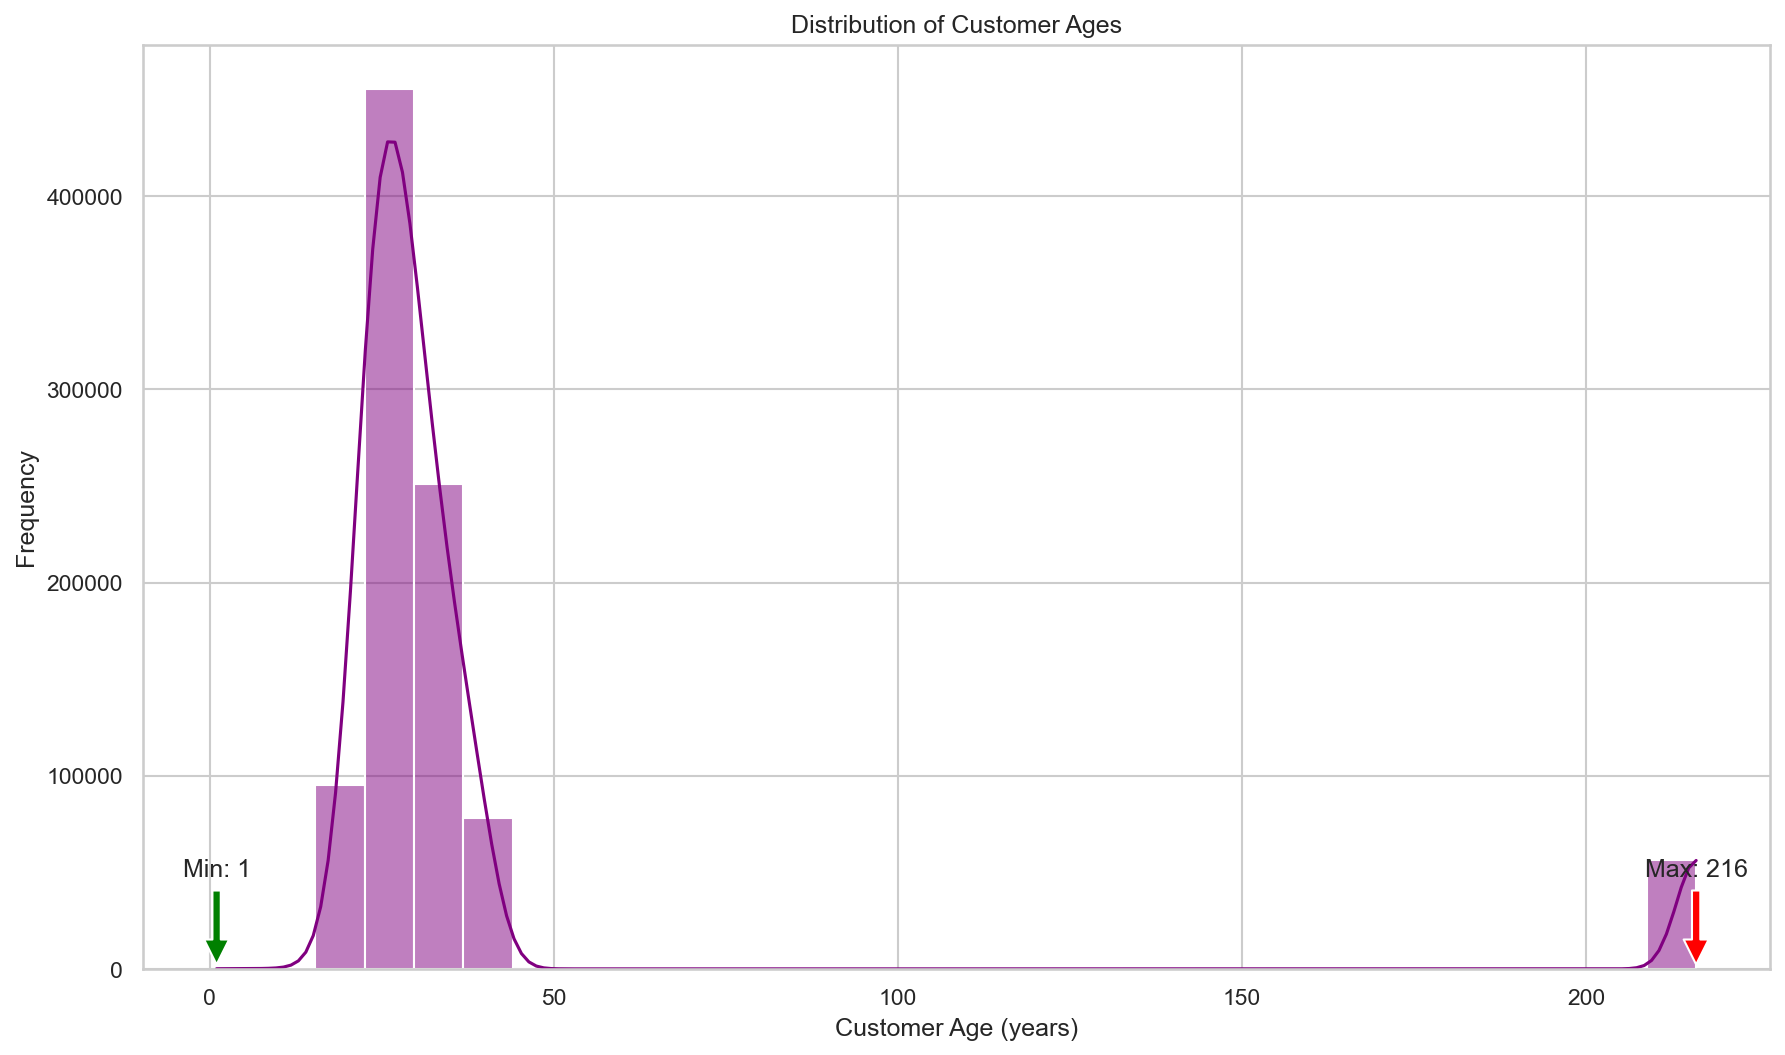

Minimum Age: 1
Maximum Age: 216


In [14]:
plt.figure(dpi=150)  #making the plot sharp and clear

#filteirng out negative and zero ages
df_positive_ages = df[df['Age'] > 0]

#plotting the histogram with KDE
sns.histplot(data = df_positive_ages, x='Age', bins=30, kde=True, color='purple')

#finding min and max ages after filtering
min_age = df_positive_ages['Age'].min()
max_age = df_positive_ages['Age'].max()

plt.title('Distribution of Customer Ages')
plt.xlabel('Customer Age (years)')
plt.ylabel('Frequency')

#getting the y-axis limits to place annotations visibly
y_min, y_max = plt.ylim()
annotation_y = y_max * 0.1  # Place annotations at 10% of max height

plt.annotate(f'Min: {min_age}', xy=(min_age, 0), xytext=(min_age, annotation_y),
             arrowprops=dict(facecolor='green', shrink=0.05),
             ha='center')

plt.annotate(f'Max: {max_age}', xy=(max_age, 0), xytext=(max_age, annotation_y),
             arrowprops=dict(facecolor='red', shrink=0.05),
             ha='center')

plt.show()

#printing the min and max below the plot
print(f"Minimum Age: {min_age}")
print(f"Maximum Age: {max_age}")

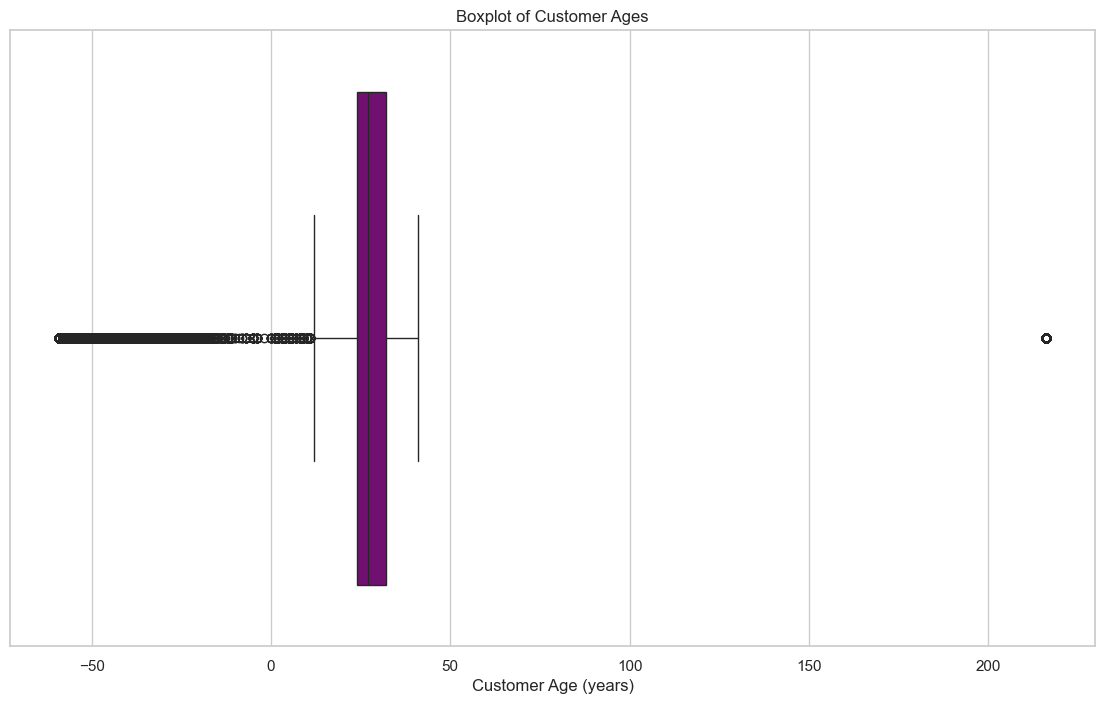

In [15]:
sns.boxplot(x=df['Age'], color= 'purple')
plt.title('Boxplot of Customer Ages')
plt.xlabel('Customer Age (years)')
plt.show()

##### &#x1F50D; The minimum and maximum ages reveal ages that are probably owned by individuals that _do not_ operate these accounts themselves or are incorrect entries. The single age above 200 is most likely an incorrect entry, along with the negative ages. However, the ages from 0 to 18 are possibly/probably accounts that were opened by parents for their children and thus operated by them, this is allowed in India (where this bank is based). Should these be dropped or kept in the dataset? Exploring further to determine this.

#### More outlier anlysis with IQR

In [16]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: 12.0, Upper bound: 44.0


In [17]:
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

outliers['Age'][outliers['Age'] >= 0].value_counts() #displaying the value counts for the non-negative outliers.

Age
216    56292
9         40
10        32
4         28
11        25
1         23
8         19
2         19
3         18
6         13
5         12
7         10
0          6
Name: count, dtype: int64

<Figure size 3000x1800 with 0 Axes>

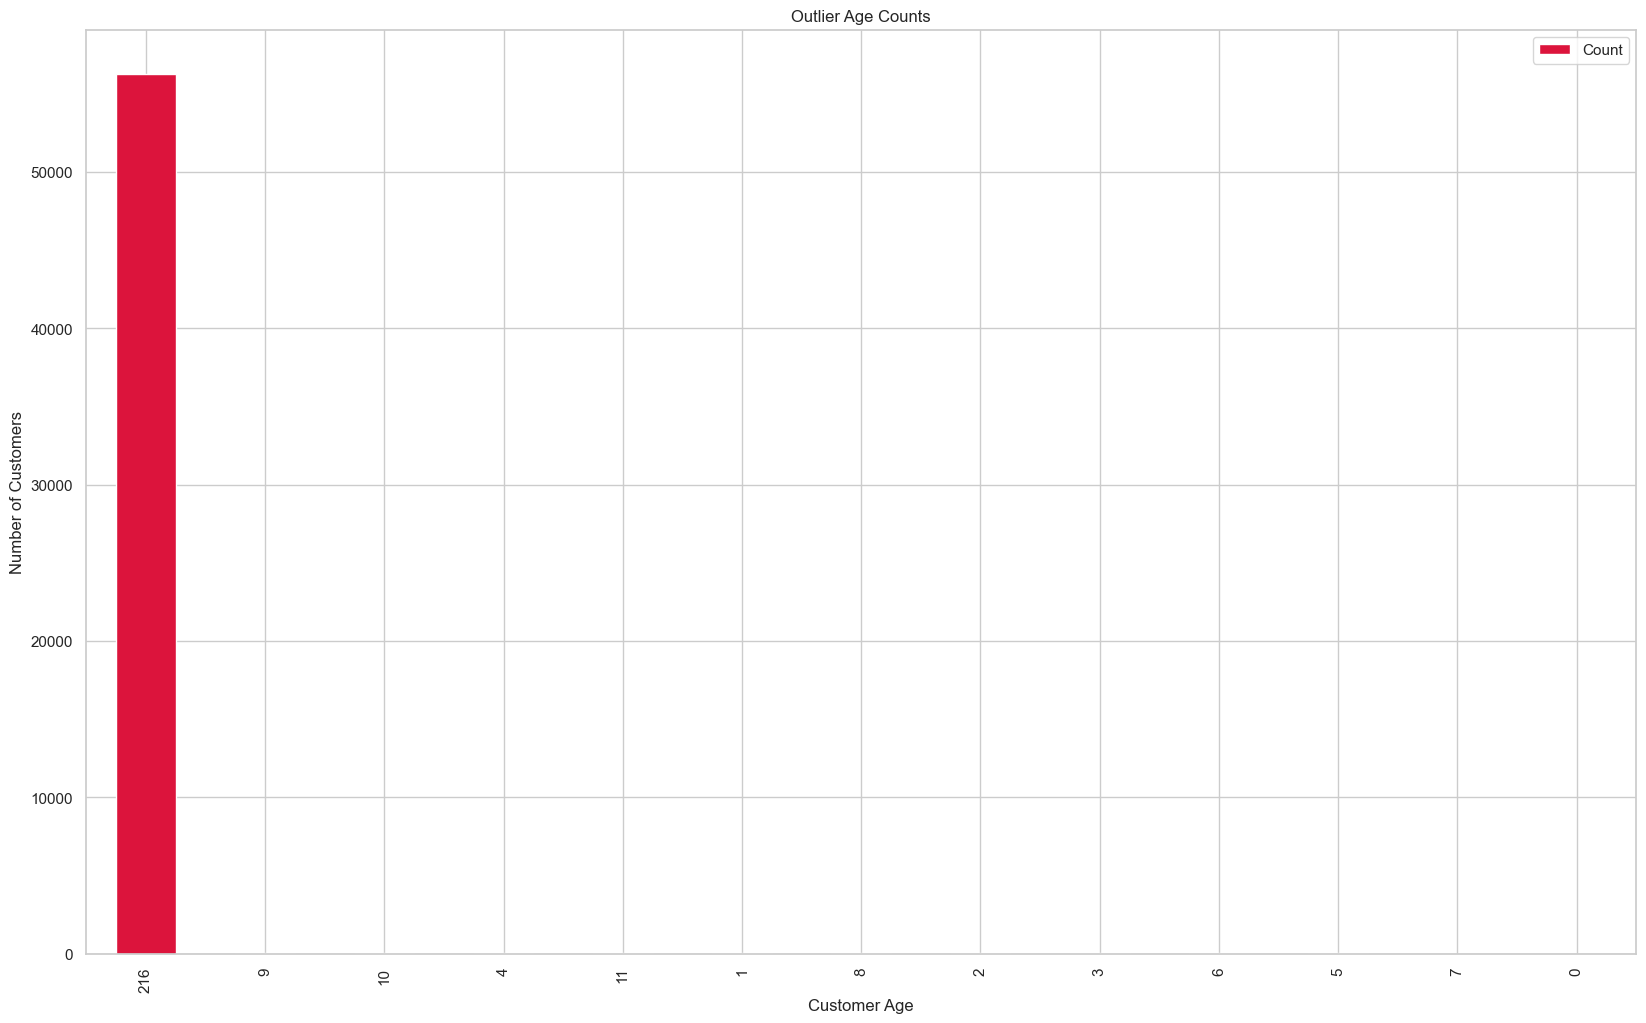

In [18]:
plt.rcParams["figure.figsize"] = (20, 12)
plt.figure(dpi=150)

#visualising this.
age_outlier_table = outliers['Age'][outliers['Age'] >= 0].value_counts().reset_index()
age_outlier_table.columns = ['Age', 'Count']  #renaming columns properly

age_outlier_table.plot(kind='bar', x='Age', y='Count', color='crimson')
plt.title('Outlier Age Counts')
plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')
plt.show()

#### &#x1F52C; Viewing the rows that have 216 as their ages. To analyse the dates of births.

In [19]:
customers_aged_216 = outliers[outliers['Age'] == 216]

customers_aged_216

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
16,T17,C1376215,1800-01-01,M,MUMBAI,77495.15,2016-08-01,124727,1423.11,216
22,T23,C7018081,1800-01-01,M,WAYS PANCHKUVA AHMEDABAD,143.07,2016-08-03,104718,110.00,216
28,T29,C7935438,1800-01-01,M,MOHALI,969436.12,2016-08-03,183634,36.90,216
34,T36,C1211387,1800-01-01,M,AHMEDABAD,11791.25,2016-08-03,125915,1075.00,216
150,T152,C3334638,1800-01-01,M,PUNE,700.00,2016-08-09,24912,1500.00,216
...,...,...,...,...,...,...,...,...,...,...
1041491,T1048444,C7261226,1800-01-01,M,BHILAI,1393.33,2016-09-18,102427,200.00,216
1041500,T1048453,C3813481,1800-01-01,M,NEW DELHI,984605.24,2016-09-18,84644,219.00,216
1041578,T1048532,C6937679,1800-01-01,M,NEW DELHI,50698.90,2016-09-18,184319,598.86,216
1041580,T1048534,C7431884,1800-01-01,M,MANDIR DHANBAD,53771.64,2016-09-18,184049,520.00,216


In [151]:
cust_aged_216 = customers_aged_216[['TransactionAmount (INR)']].value_counts(ascending=False)

cust_aged_216

TransactionAmount (INR)
1000.00                    2725
500.00                     2070
2000.00                    1122
200.00                     1079
100.00                     1002
                           ... 
454.76                        1
454.10                        1
2681.28                       1
2681.38                       1
557000.73                     1
Name: count, Length: 14215, dtype: int64

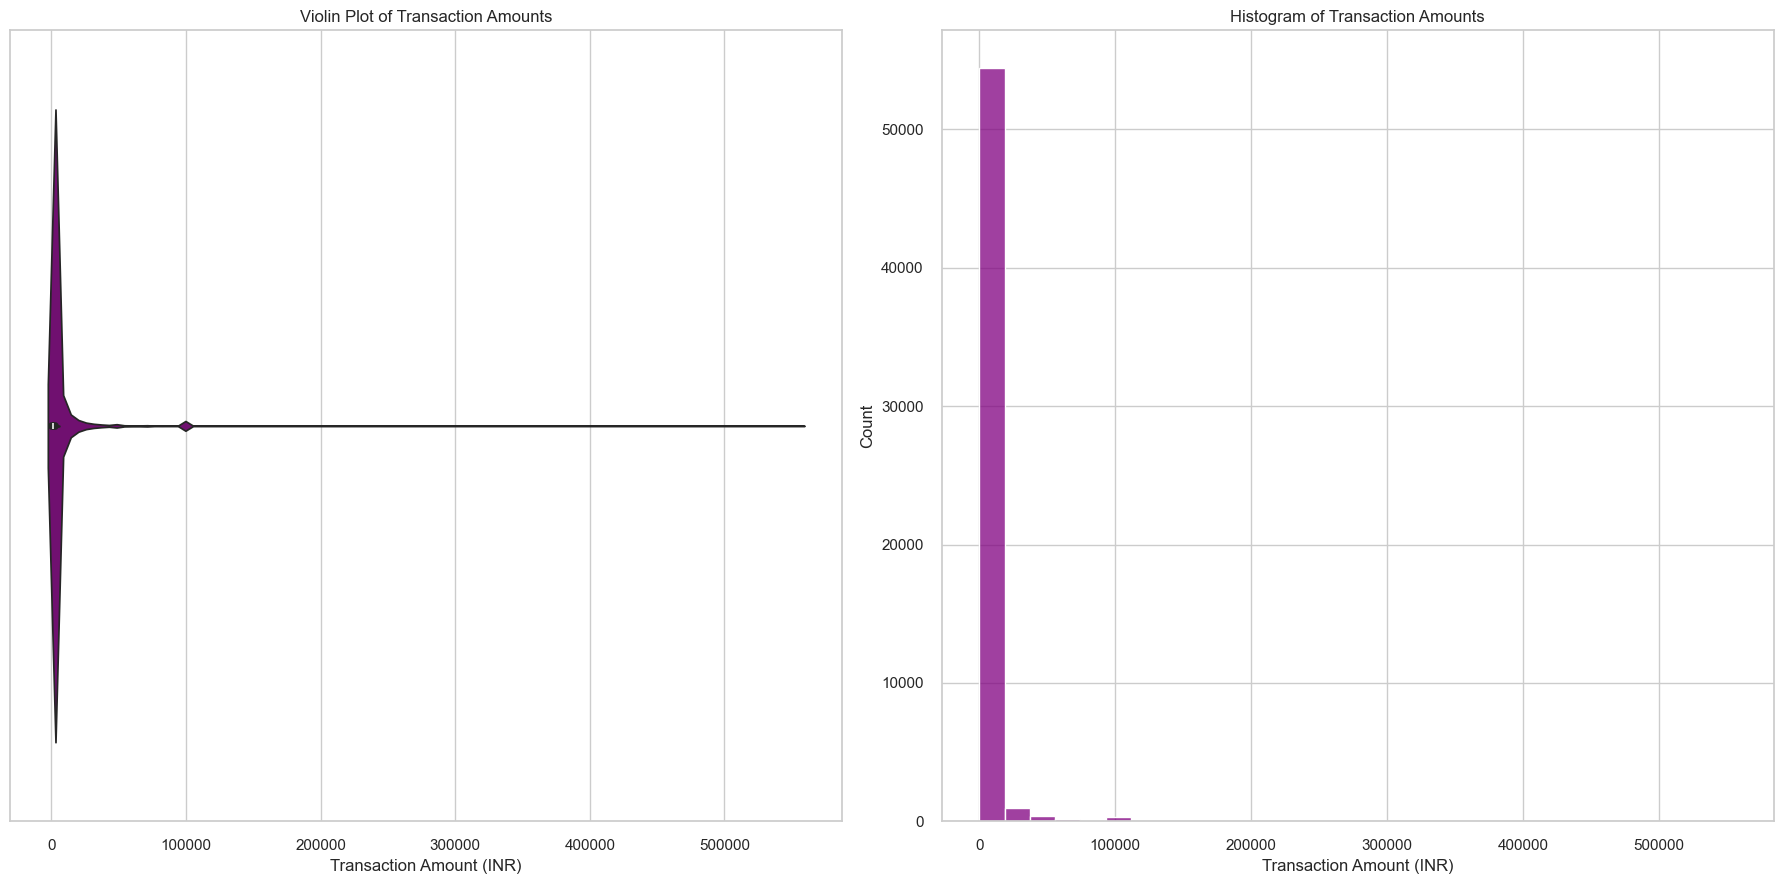

In [145]:
#plotting violin plot and distogram to visualise the values. 
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

#violin plot (left)
sns.violinplot(x=customers_aged_216['TransactionAmount (INR)'], color='purple', ax=axes[0])
axes[0].set_title('Violin Plot of Transaction Amounts')
axes[0].set_xlabel('Transaction Amount (INR)')

#histogram (right)
sns.histplot(customers_aged_216['TransactionAmount (INR)'], bins=30, color='purple', ax=axes[1])
axes[1].set_title('Histogram of Transaction Amounts')
axes[1].set_xlabel('Transaction Amount (INR)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

##### 💡 From the plots, it can be observed that most are **low transaction** amounts, so they would be safe to drop if that is decided, without cutting out many/most high-value customers from RFM analysis.

#### &#x2757;Confirming "1800-01-01" is the only Date of Birth for these customers, as it is incorrect and was most likely just a default value in the system.

In [20]:
customers_aged_216['CustomerDOB'].unique() #checking the unique dates of birth for these rows.

<DatetimeArray>
['1800-01-01 00:00:00']
Length: 1, dtype: datetime64[ns]

#### DROPPING THE ROWS WHERE THE AGES ARE 216.

##### The "216" ages will be dropped, as they are clearly incorrect (1800-01-01 is usually default value in a lot of data entry systems) and about 5% of the data. But the rest of the outliers (0 and above) may be parents who opened accounts for their children, so these will be kept. 

In [21]:
print(f"The number of rows to be dropped is {len(df[df['Age'] == 216])}, which is {len(df[df['Age'] == 216])/len(df) * 100}% of the data")

The number of rows to be dropped is 56292, which is 5.404305241673019% of the data


In [22]:
#dropping the rows where age is 216.
df_clean = df[df['Age'] != 216]

df_clean

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,22
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,-41
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,19
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,-58
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,28
...,...,...,...,...,...,...,...,...,...,...
1041609,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,184824,799.0,26
1041610,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0,24
1041611,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,183313,770.0,27
1041612,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0,38


#### FIXING THE FUTURE-LOOKING BIRTH YEARS.

In [23]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 985322 entries, 0 to 1041613
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   TransactionID            985322 non-null  object        
 1   CustomerID               985322 non-null  object        
 2   CustomerDOB              985322 non-null  datetime64[ns]
 3   CustGender               985322 non-null  object        
 4   CustLocation             985322 non-null  object        
 5   CustAccountBalance       985322 non-null  float64       
 6   TransactionDate          985322 non-null  datetime64[ns]
 7   TransactionTime          985322 non-null  int64         
 8   TransactionAmount (INR)  985322 non-null  float64       
 9   Age                      985322 non-null  int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(4)
memory usage: 82.7+ MB


#### Viewing the age distribution of the data without the negative age rows.

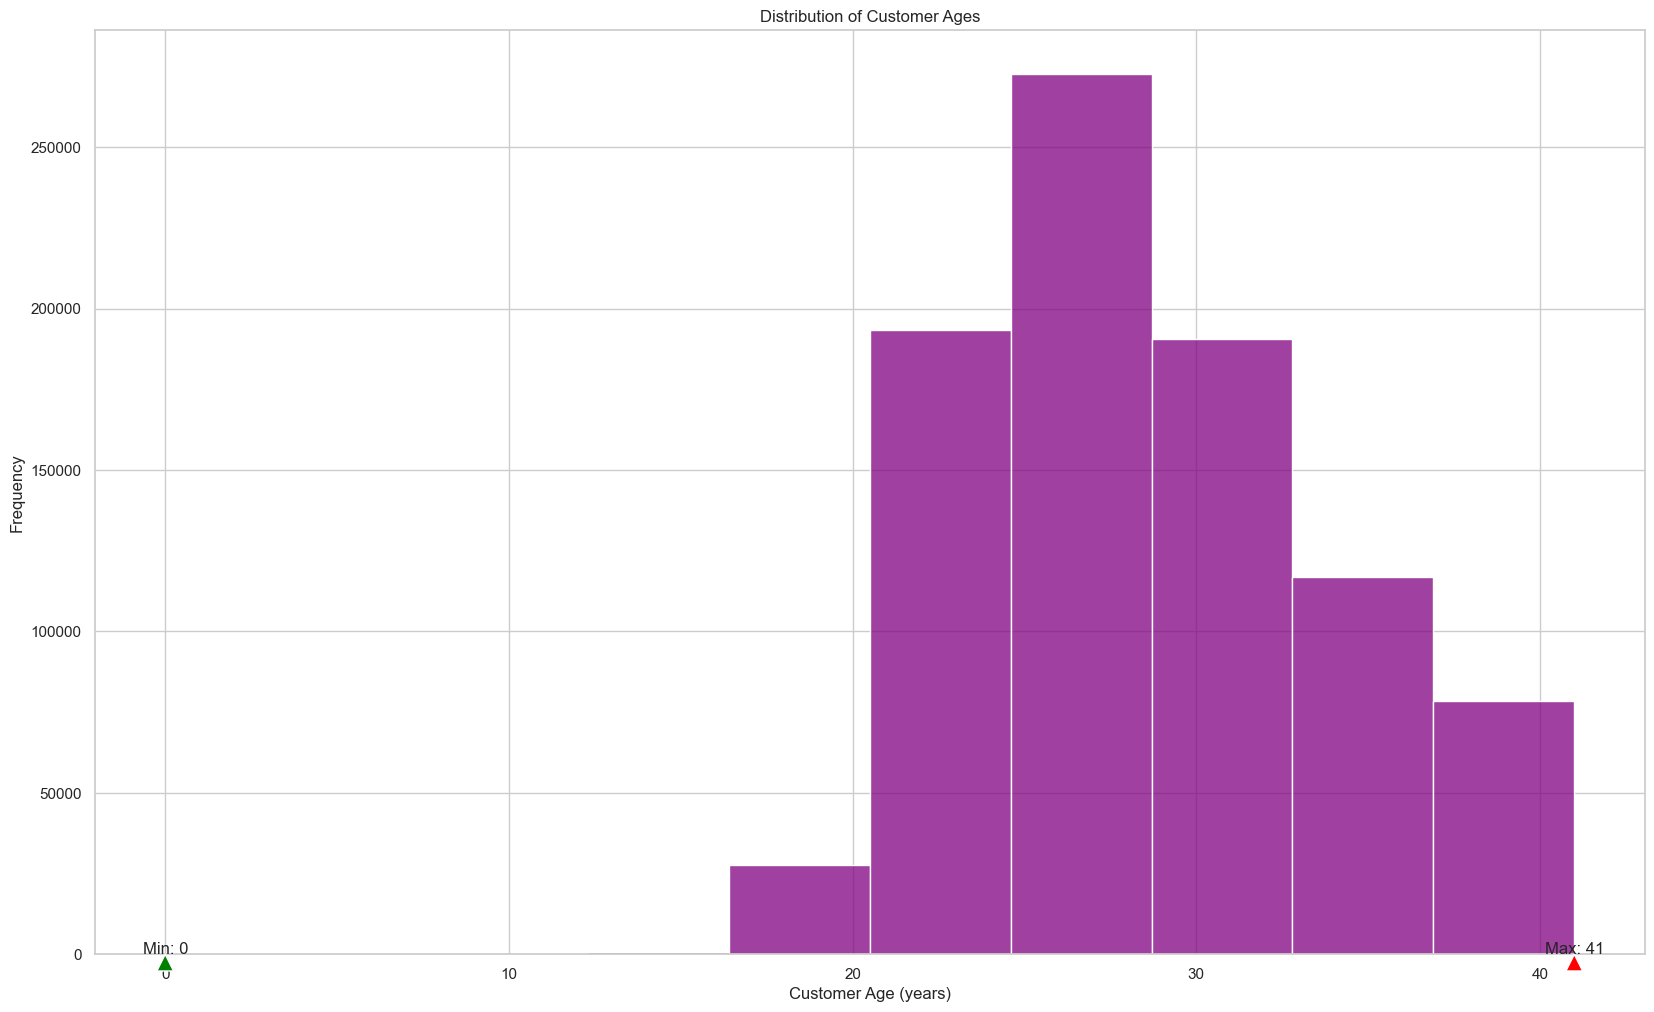

Minimum Age: 0
Maximum Age: 41


In [24]:
#filter for non-negative ages
positive_ages_df = df_clean[df_clean['Age'] >= 0]

# Find min and max ages
min_age = positive_ages_df['Age'].min()
max_age = positive_ages_df['Age'].max()

#plotting
sns.histplot(positive_ages_df['Age'], bins=10, kde=False, color='purple')
plt.title('Distribution of Customer Ages')
plt.xlabel('Customer Age (years)')
plt.ylabel('Frequency')

# Annotating min and max
plt.annotate(f'Min: {min_age}', xy=(min_age, 0), xytext=(min_age, 5),
             arrowprops=dict(facecolor='green', shrink=0.05),
             ha='center')

plt.annotate(f'Max: {max_age}', xy=(max_age, 0), xytext=(max_age, 5),
             arrowprops=dict(facecolor='red', shrink=0.05),
             ha='center')

plt.show()

# Printing min and max
print(f"Minimum Age: {min_age}")
print(f"Maximum Age: {max_age}")

#### &#x1F4C3; It appears that the max age in this case would now be 41, and the min would be 0, this is not very realistic, as life expectancy in India in 2016 was ~70 (Source: https://data.who.int/countries/356). Therefore, it would make sense to infer that the future-looking DOBs resulted from a 2-digit year expansion gone wrong, which is common when parsing YY formats. Subtracting 100 from these years to correct the error.

In [25]:
df_clean

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,22
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,-41
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,19
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,-58
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,28
...,...,...,...,...,...,...,...,...,...,...
1041609,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,184824,799.0,26
1041610,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0,24
1041611,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,183313,770.0,27
1041612,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0,38


In [26]:
#fixing two-digit years: assume if age < 0, subtract 100 years
def fix_negative_dob(dob):
    if dob.year > 2016:
        return dob.replace(year = dob.year - 100) #only for those rows which satisfy the > 2016 year condition.
    return dob #other rows would return their present years.

df_clean = df_clean.copy()

#applying to the column
df_clean['CustomerDOB'] = df_clean['CustomerDOB'].apply(fix_negative_dob)

#recalculate Age using TransactionDate
df_clean['Age'] = df_clean['TransactionDate'].dt.year - df_clean['CustomerDOB'].dt.year

df_clean #viewing the clean dataframe.

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,22
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,59
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,20
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,43
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,28
...,...,...,...,...,...,...,...,...,...,...
1041609,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,184824,799.0,26
1041610,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460.0,24
1041611,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,183313,770.0,27
1041612,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000.0,38


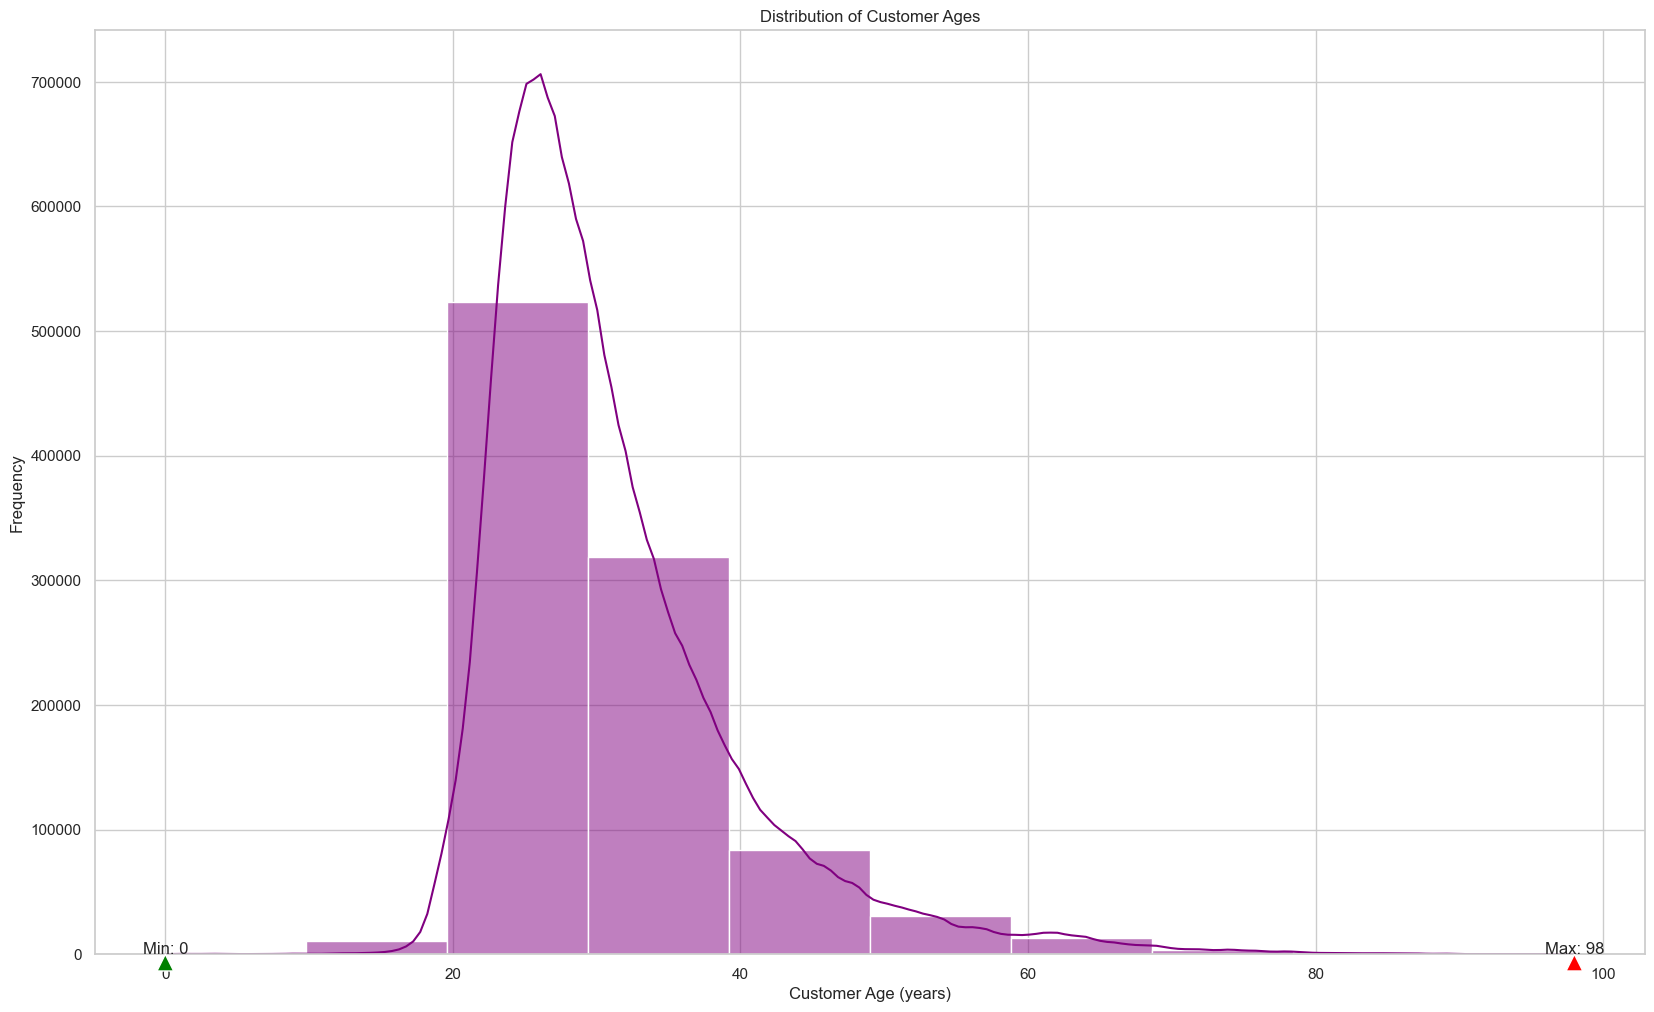

Minimum Age: 0
Maximum Age: 98


In [27]:
#minimum and maximum ages.
min_age = df_clean['Age'].min()
max_age = df_clean['Age'].max()

#plotting
sns.histplot(df_clean['Age'], bins=10, kde=True, color='purple')
plt.title('Distribution of Customer Ages')
plt.xlabel('Customer Age (years)')
plt.ylabel('Frequency')

# Annotating min and max
plt.annotate(f'Min: {min_age}', xy=(min_age, 0), xytext=(min_age, 5),
             arrowprops=dict(facecolor='green', shrink=0.05),
             ha='center')

plt.annotate(f'Max: {max_age}', xy=(max_age, 0), xytext=(max_age, 5),
             arrowprops=dict(facecolor='red', shrink=0.05),
             ha='center')

plt.show()

# Printing min and max
print(f"Minimum Age: {min_age}")
print(f"Maximum Age: {max_age}")

#### &#x2728; This is a more robust distribution of ages and therefore the more fitting option for handling those values, rather than dropping. It can be observed that most of the customers fall between 20 - 30/40 years

### _GENDER._
Viewing the distribution of customers by gender and any insights from it.

In [28]:
#verifying the genders present.

df_clean['CustGender'].unique()

array(['F', 'M'], dtype=object)

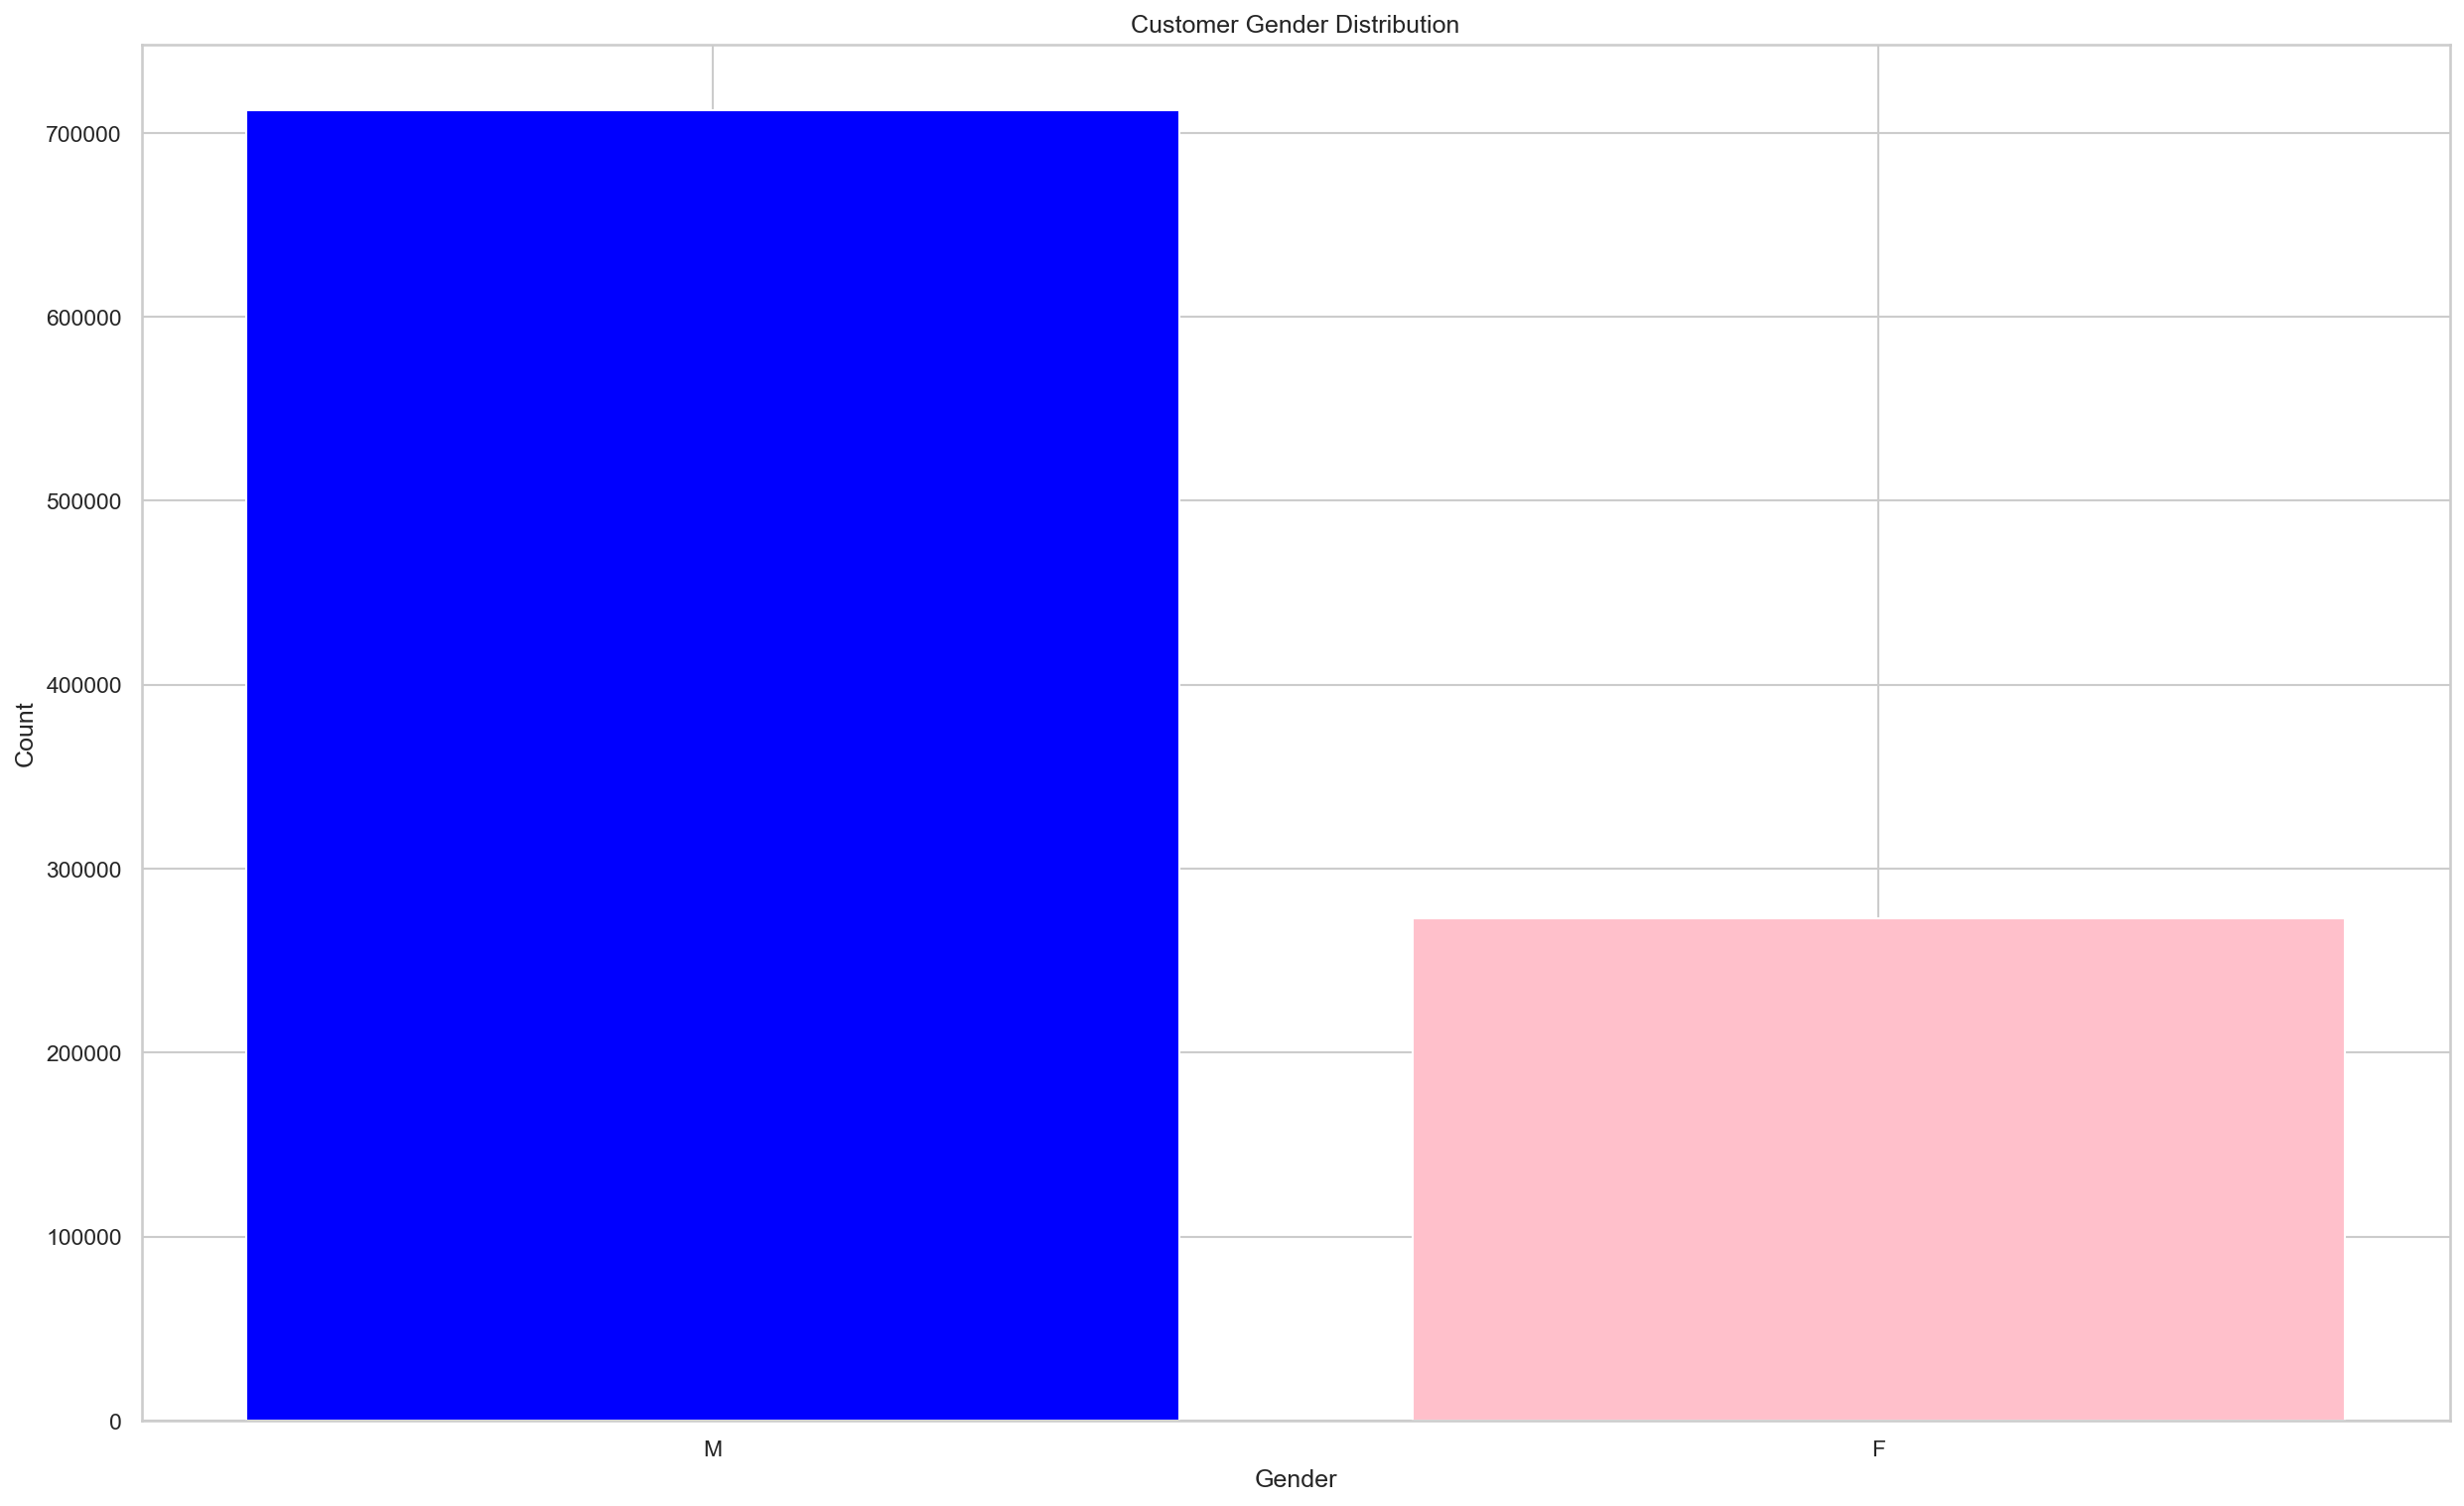

In [29]:
#filteirng for genders only.
gender_counts = df_clean['CustGender'].value_counts()

#defining colors
colors = {'M': 'blue', 'F': 'pink'}

#plotting
plt.figure(dpi=150)
plt.rcParams["figure.figsize"] = (10, 8)
plt.bar(gender_counts.index, gender_counts.values, color=[colors[g] for g in gender_counts.index])
plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

#### The plot shows that there are a lot more male customers than female.

In [30]:
gender_counts

CustGender
M    712454
F    272868
Name: count, dtype: int64

### _LOCATION._

In [31]:
df_clean['CustLocation'].value_counts()

CustLocation
MUMBAI                       97679
BANGALORE                    77751
NEW DELHI                    76380
GURGAON                      70518
DELHI                        67335
                             ...  
KAMALPUR                         1
JUFFAIR                          1
CHAKALA ANDHERI -E MUMBAI        1
CORPORATION THANE                1
IMPERIA THANE WEST               1
Name: count, Length: 8164, dtype: int64

In [32]:
df_clean['CustLocation'].nunique()

8164

In [33]:
df_clean[df_clean['CustLocation'] == " "] #checking if any empty strings are present.

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age


#### Top 20 locations.

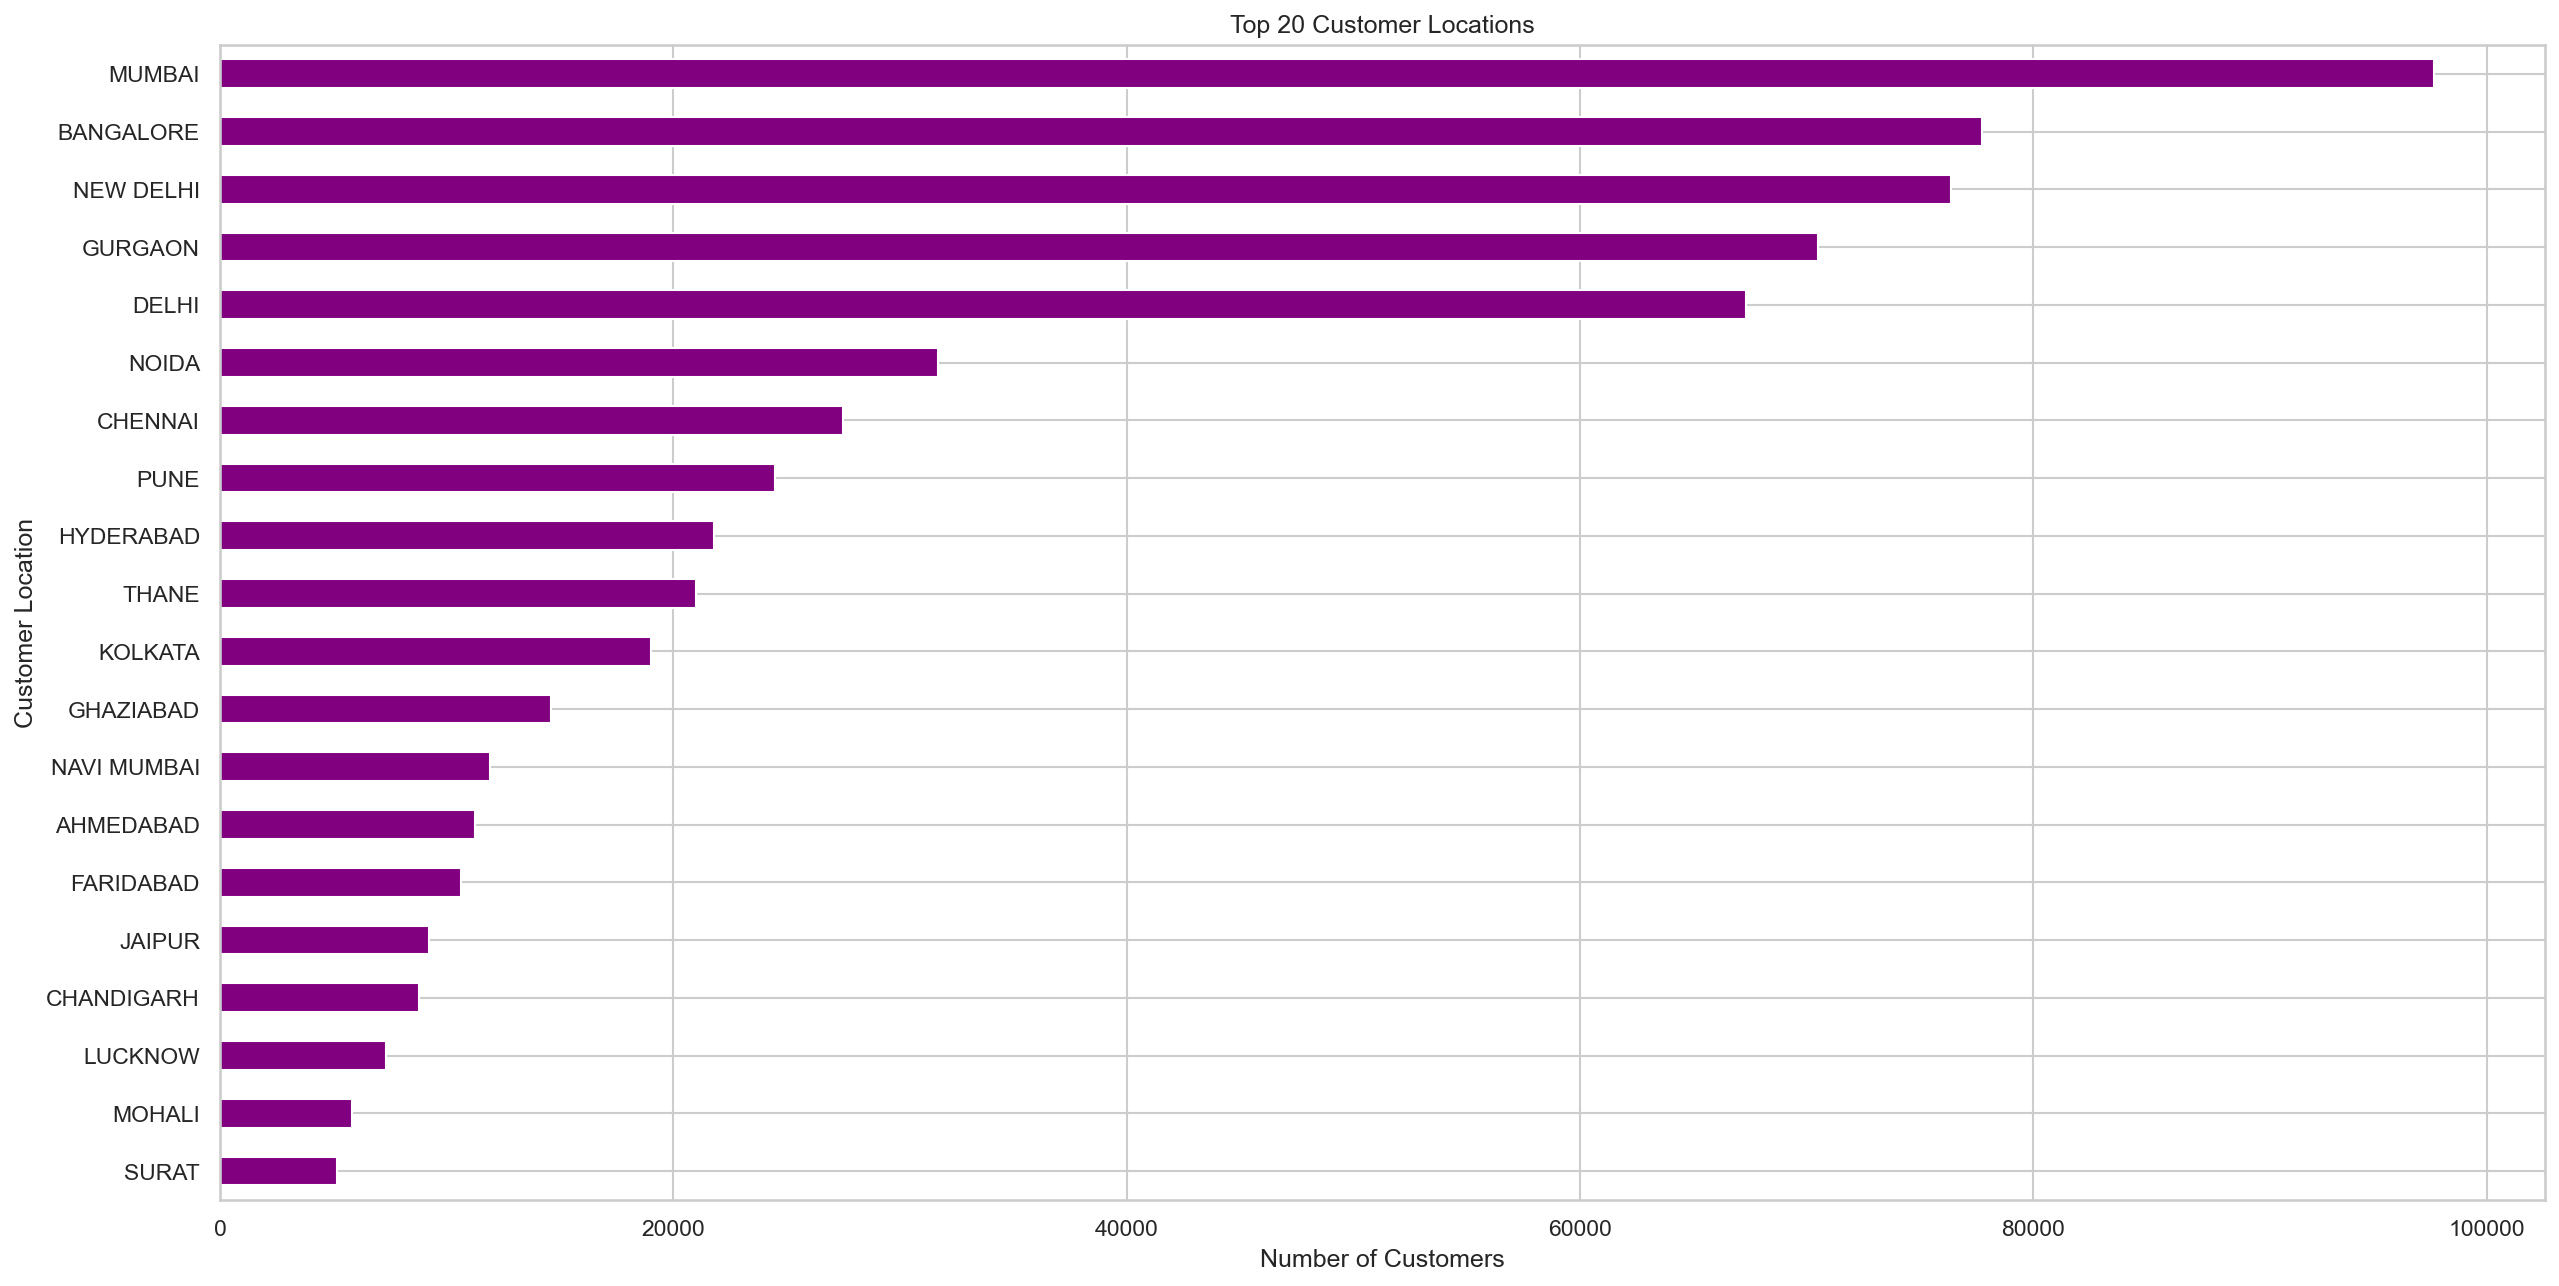

In [34]:
#filtering for the top 20 locations
top_20_locations = df_clean['CustLocation'].value_counts().head(20)

#plotting this on a horizontal bar chart.
plt.figure(dpi=150, figsize=(20, 10))
top_20_locations.plot(kind='barh', color= 'purple')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Location')
plt.title('Top 20 Customer Locations')
plt.gca().invert_yaxis()  #so the largest bar is at the top, descending order.
plt.show()

#### 🏙️ The most transactions were done in **Mumbai**, which makes sense as Mumbai is one of the most populated cities in India (Source: https://www.statista.com/statistics/275378/largest-cities-in-india/). The fact that other large cities (such as Delhi) are not at the top of this plot may suggest that customers there prefer transacting with other, more popular banks. This could indicate a need for more advertising, marketing and targeted campaigns in those cities.

### _ACCOUNT BALANCE._

In [35]:
#viewing the account balance of customers.
df_clean['CustAccountBalance'].sort_values(ascending = False)

651595    115035495.1
870418    115035495.1
783590    115035495.1
873636    115035495.1
996102    115035495.1
             ...     
243592            0.0
543312            0.0
765593            0.0
243527            0.0
258820            0.0
Name: CustAccountBalance, Length: 985322, dtype: float64

##### &#x1F4B0; Account Balances of 0 are fine, because Transaction Amount is the column being used for RFM analysis. Will look into that.

### _TRANSACTION AMOUNT._

In [36]:
df_clean['TransactionAmount (INR)'].sort_values(ascending = False)

396280    1560034.99
574916    1380002.88
528263     991132.22
744124     724122.00
56155      720001.16
             ...    
645714          0.00
278581          0.00
553512          0.00
839875          0.00
345556          0.00
Name: TransactionAmount (INR), Length: 985322, dtype: float64

In [37]:
#checking to see the number of rows with 0 transaction amount.

len(df_clean[df_clean['TransactionAmount (INR)'] == 0])

708

In [38]:
#dropping those rows.

df_clean.query('`TransactionAmount (INR)` != 0', inplace=True)

In [39]:
#checking again to see the number of rows with 0 transaction amount.

len(df_clean[df_clean['TransactionAmount (INR)'] == 0])

0

In [40]:
#checking the datatypes of the columns in te dataset.

df_clean.dtypes

TransactionID                      object
CustomerID                         object
CustomerDOB                datetime64[ns]
CustGender                         object
CustLocation                       object
CustAccountBalance                float64
TransactionDate            datetime64[ns]
TransactionTime                     int64
TransactionAmount (INR)           float64
Age                                 int32
dtype: object

### _TRANSACTION TIME._

In [41]:
#viewing the values in the column

df_clean['TransactionTime'].unique()

array([143207, 141858, 142712, ...,  65244,  81817,  71955],
      shape=(81343,))

##### &#x23F1; The time format is incorrect. Fixing this.

In [42]:
df_clean['TransactionTime'] = df_clean['TransactionTime'].astype(str).str.zfill(6)

#converting to HH:MM:SS format string
df_clean['TransactionTime'] = df_clean['TransactionTime'].str[:2] + ':' + \
                              df_clean['TransactionTime'].str[2:4] + ':' + \
                              df_clean['TransactionTime'].str[4:6]

In [43]:
df_clean

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,14:32:07,25.0,22
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,14:18:58,27999.0,59
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,14:27:12,459.0,20
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0,43
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,18:11:56,1762.5,28
...,...,...,...,...,...,...,...,...,...,...
1041609,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,18:48:24,799.0,26
1041610,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,18:37:34,460.0,24
1041611,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,18:33:13,770.0,27
1041612,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,18:47:06,1000.0,38


## 🔍 EDA

In [44]:
#checking the updated structure of the data.

df_clean.shape

(984614, 10)

In [45]:
#checking how many unique customer IDs are present in the dataset.

print(f"The number of unique customer IDs is {df_clean["CustomerID"].nunique()}")

The number of unique customer IDs is 838561


In [46]:
#viewing the sorted unique transaction dates
transaction_dates = sorted(df_clean["TransactionDate"].unique())
print("Transaction Dates:")
transaction_dates

Transaction Dates:


[Timestamp('2016-08-01 00:00:00'),
 Timestamp('2016-08-02 00:00:00'),
 Timestamp('2016-08-03 00:00:00'),
 Timestamp('2016-08-04 00:00:00'),
 Timestamp('2016-08-05 00:00:00'),
 Timestamp('2016-08-06 00:00:00'),
 Timestamp('2016-08-07 00:00:00'),
 Timestamp('2016-08-08 00:00:00'),
 Timestamp('2016-08-09 00:00:00'),
 Timestamp('2016-08-10 00:00:00'),
 Timestamp('2016-08-11 00:00:00'),
 Timestamp('2016-08-12 00:00:00'),
 Timestamp('2016-08-13 00:00:00'),
 Timestamp('2016-08-14 00:00:00'),
 Timestamp('2016-08-15 00:00:00'),
 Timestamp('2016-08-16 00:00:00'),
 Timestamp('2016-08-17 00:00:00'),
 Timestamp('2016-08-18 00:00:00'),
 Timestamp('2016-08-19 00:00:00'),
 Timestamp('2016-08-20 00:00:00'),
 Timestamp('2016-08-21 00:00:00'),
 Timestamp('2016-08-22 00:00:00'),
 Timestamp('2016-08-23 00:00:00'),
 Timestamp('2016-08-24 00:00:00'),
 Timestamp('2016-08-25 00:00:00'),
 Timestamp('2016-08-26 00:00:00'),
 Timestamp('2016-08-27 00:00:00'),
 Timestamp('2016-08-28 00:00:00'),
 Timestamp('2016-08-

##### &#x1F4C5; Only transactions from months 8, 9, and 10 (August, September and October) are present in this dataset.

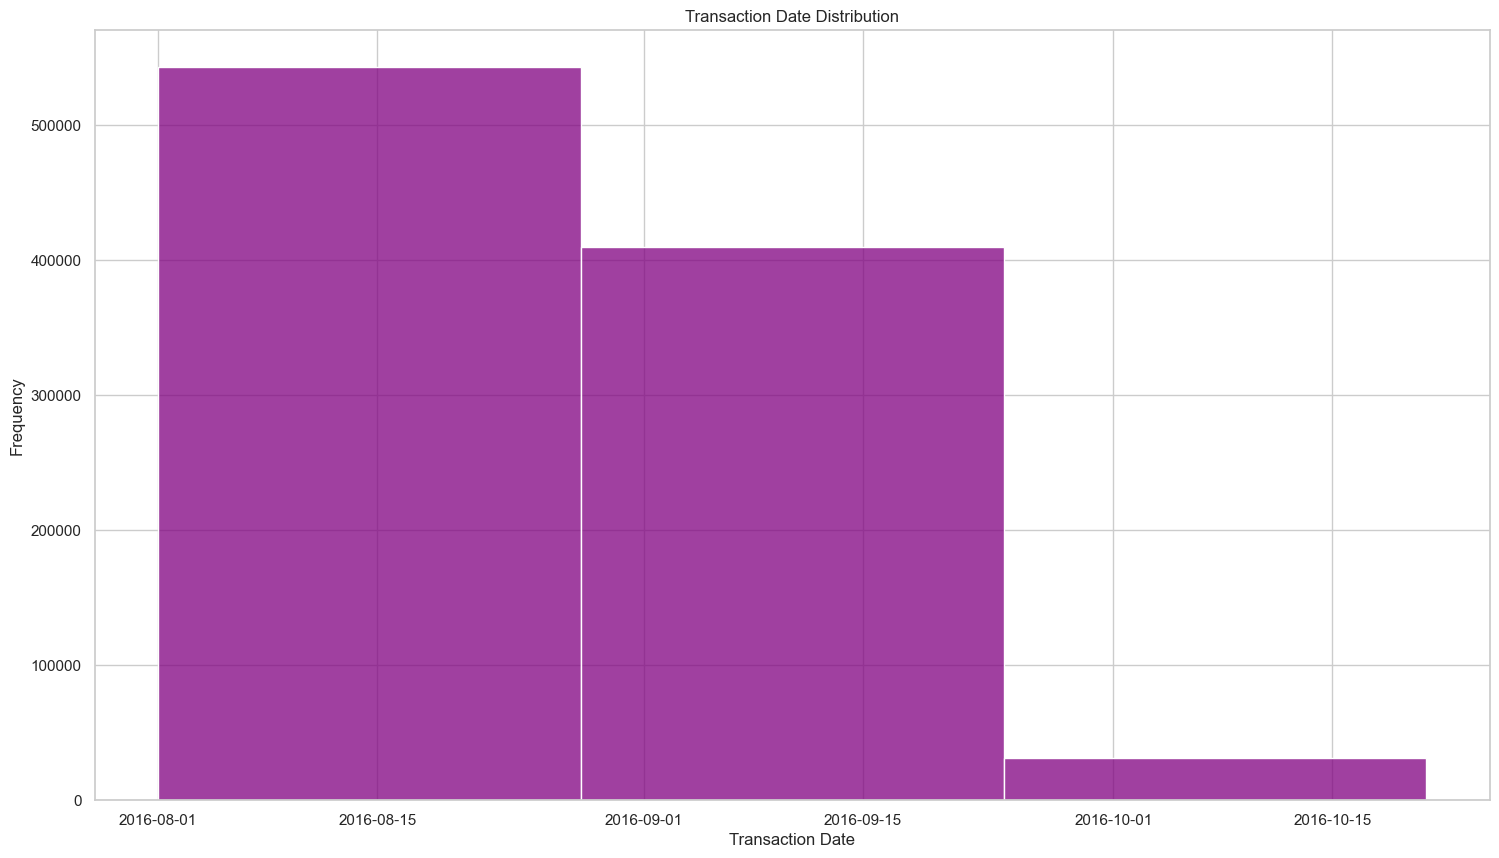

In [47]:
#plotting the distribution of transactions across unique transaction dates
plt.figure(figsize=(18, 10))
sns.histplot(df_clean["TransactionDate"], bins = 3, color = 'purple') #3 for the three months present.
plt.xlabel("Transaction Date")
plt.ylabel("Frequency")
plt.title("Transaction Date Distribution")
plt.show()

##### &#x1F46B; Checking the updated distribution of gender in the data after cleaning.

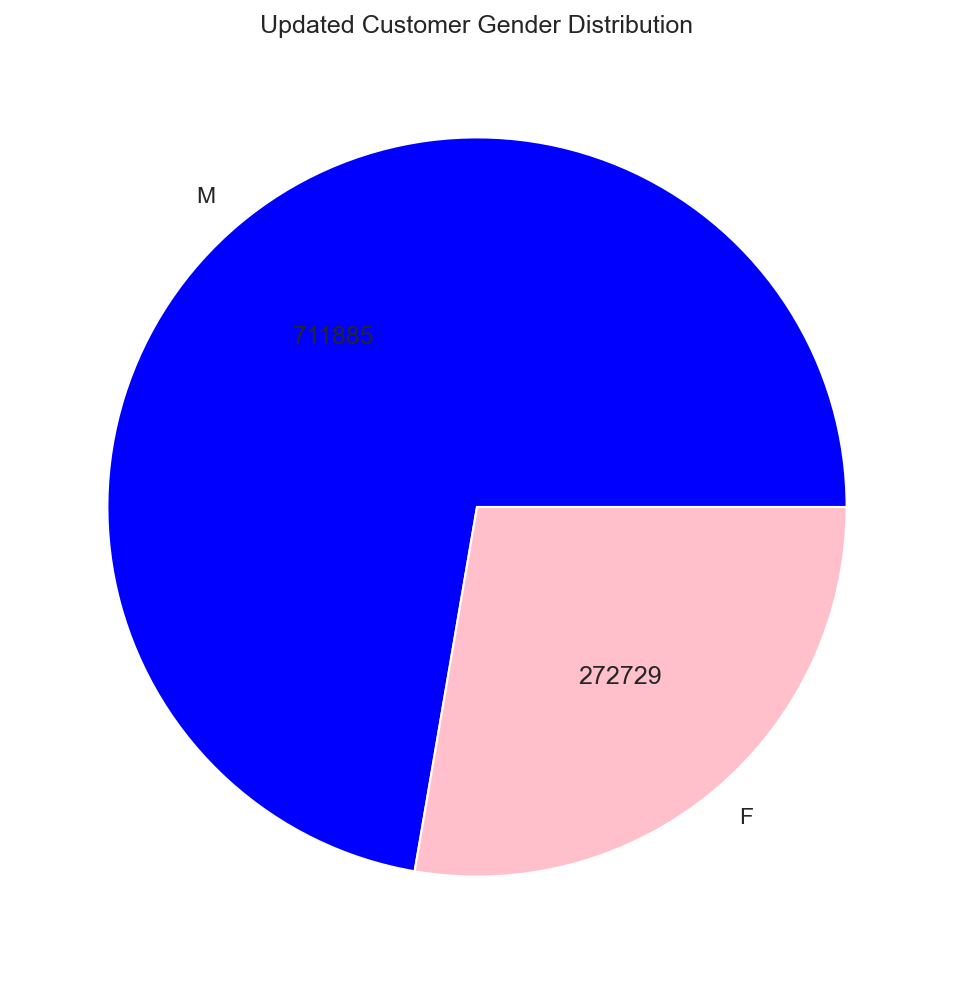

In [48]:
#checking the new distribution of gender data after cleaning
updated_gender_counts = df_clean['CustGender'].value_counts()

#defining colors
colors = {'M': 'blue', 'F': 'pink'}

#function to display actual counts on the pie chart
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{count}'
    return my_autopct

#plotting
plt.figure(dpi=150)
plt.rcParams["figure.figsize"] = (4, 4)
plt.pie(
    updated_gender_counts.values,
    labels=updated_gender_counts.index,
    colors=[colors[g] for g in updated_gender_counts.index],
    autopct=make_autopct(updated_gender_counts.values)
)
plt.title('Updated Customer Gender Distribution')
plt.show()

In [49]:
#calculating total count
total_count = updated_gender_counts.sum()

#calculating the percentages
gender_percentages = (updated_gender_counts / total_count) * 100

#showing the percentages
for gender, percentage in gender_percentages.items():
    print(f'{gender}: {percentage:.2f}%')

M: 72.30%
F: 27.70%


##### About 72% of the customers are male, this may skew the data in some way, however, it is worth noting.

In [166]:
df_clean

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,14:32:07,25.0,22
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,14:18:58,27999.0,59
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,14:27:12,459.0,20
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0,43
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,18:11:56,1762.5,28
...,...,...,...,...,...,...,...,...,...,...
1041609,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,18:48:24,799.0,26
1041610,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,18:37:34,460.0,24
1041611,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,18:33:13,770.0,27
1041612,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,18:47:06,1000.0,38


## 📊 RFM ANALYSIS.

RFM analysis is a marketing tool used to evaluate and segment customers based on three factors:

🕒 Recency (R): How recently a customer made a purchase.

🔁 Frequency (F): How often a customer makes purchases.

💰 Monetary (M): How much money a customer spends on purchases.

By analysing these three factors, BankTrust can identify their most valuable customers, understand purchasing patterns, and create targeted marketing strategies. Basically, customers who purchased recently, purchase often, and spend a lot are usually considered high-value customers.

### _RECENCY._

In [50]:
df_clean.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,14:32:07,25.0,22
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,14:18:58,27999.0,59
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,14:27:12,459.0,20
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0,43
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,18:11:56,1762.5,28


In [51]:
#checing the most recent date.
most_recent_date = df_clean['TransactionDate'].max()

#viewing this.
most_recent_date

Timestamp('2016-10-21 00:00:00')

In [53]:
#getting the most recent transaction date per customer.
recency = df_clean.groupby('CustomerID')['TransactionDate'].max().reset_index()
recency['Recency'] = (most_recent_date - recency['TransactionDate']).dt.days

#display.
recency

,CustomerID,TransactionDate,Recency
0,C1010011,2016-09-26,25
1,C1010012,2016-08-14,68
2,C1010014,2016-08-07,75
3,C1010018,2016-09-15,36
4,C1010024,2016-08-18,64
...,...,...,...
838556,C9099836,2016-08-07,75
838557,C9099877,2016-09-15,36
838558,C9099919,2016-08-18,64
838559,C9099941,2016-08-28,54


##### ✨ A recency value of 0 would mean a customer performed a transaction on the most recent date in the data.

### _FREQUENCY._

In [54]:
#making sure there are no duplicated Transaction IDs and then calculate frequency per customer
frequency = df_clean.drop_duplicates(subset='TransactionID').groupby('CustomerID')['TransactionID'].count().reset_index()
frequency.rename(columns={'TransactionID': 'Frequency'}, inplace=True)

#display table
frequency.head()

,CustomerID,Frequency
0,C1010011,2
1,C1010012,1
2,C1010014,2
3,C1010018,1
4,C1010024,1


In [55]:
frequency.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838561 entries, 0 to 838560
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   CustomerID  838561 non-null  object
 1   Frequency   838561 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 12.8+ MB


### _MONETARY._

In [56]:
#making sure there are no duplicated Transaction IDs and then calculate monetary value/spend per customer
monetary = df_clean.drop_duplicates(subset='TransactionID').groupby('CustomerID')['TransactionAmount (INR)'].sum().reset_index()
monetary.rename(columns={'TransactionAmount (INR)': 'Monetary'}, inplace=True)

#display table
monetary.head()

,CustomerID,Monetary
0,C1010011,5106.0
1,C1010012,1499.0
2,C1010014,1455.0
3,C1010018,30.0
4,C1010024,5000.0


### _RFM TABLE CREATION._

In [57]:
#merging recency, frequency, and monetary
rfm = recency.merge(frequency, on='CustomerID').merge(monetary, on='CustomerID')

#display resulting df
rfm.head()

,CustomerID,TransactionDate,Recency,Frequency,Monetary
0,C1010011,2016-09-26,25,2,5106.0
1,C1010012,2016-08-14,68,1,1499.0
2,C1010014,2016-08-07,75,2,1455.0
3,C1010018,2016-09-15,36,1,30.0
4,C1010024,2016-08-18,64,1,5000.0


In [58]:
#making the customer ID column the index of the df

rfm.set_index('CustomerID', inplace=True)

rfm #viewing

,TransactionDate,Recency,Frequency,Monetary
CustomerID,,,,
C1010011,2016-09-26,25,2,5106.0
C1010012,2016-08-14,68,1,1499.0
C1010014,2016-08-07,75,2,1455.0
C1010018,2016-09-15,36,1,30.0
C1010024,2016-08-18,64,1,5000.0
...,...,...,...,...
C9099836,2016-08-07,75,1,691.0
C9099877,2016-09-15,36,1,222.0
C9099919,2016-08-18,64,1,126.0


#### Exploring the RFM table

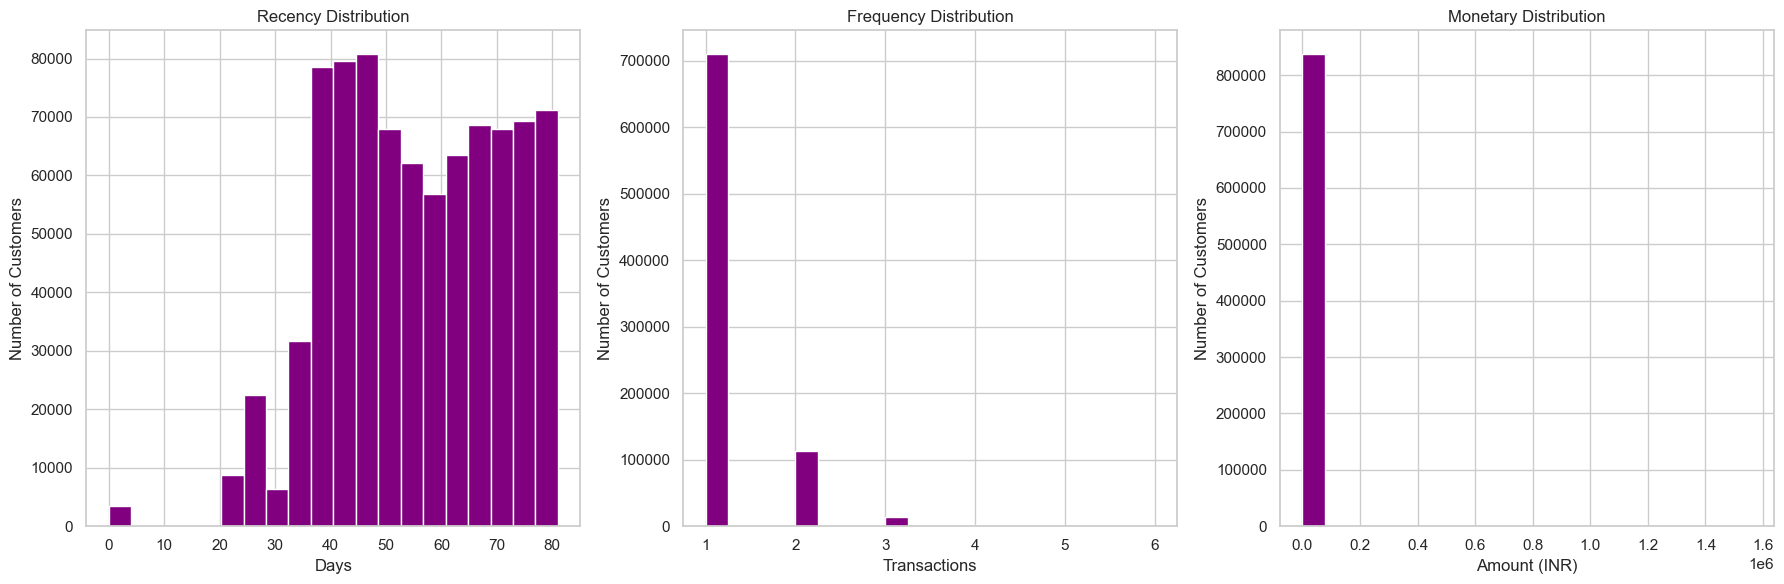

In [59]:
#plot with 3 subplots
fig, axis = plt.subplots(1, 3, figsize = (18, 6))

#column names and titles
columns = ['Recency', 'Frequency', 'Monetary']
titles = ['Recency Distribution', 'Frequency Distribution', 'Monetary Distribution']
xlabels = ['Days', 'Transactions', 'Amount (INR)']

#loop over each plot
for i, col in enumerate(columns):
    axis[i].hist(rfm[col], bins=20, color='purple')
    axis[i].set_title(titles[i])
    axis[i].set_xlabel(xlabels[i])
    axis[i].set_ylabel('Number of Customers')

plt.tight_layout() #for proper spacing of features.
plt.show()

🕒 The recency plot reveals that the transaction window is short, which was expected since the data only spans a period of three months (August to October). The max recency values is about 80, with most customers' recent transactions being around the 40 day mark.

🔁 The frequency plot shows that most customers made one transaction and a few had a little above one transaction, which is not what we would like to see.

💰 The monetary plot is hard to interpret, as the scale makes all customers' data appear around an amount of 0-0.1. This would need to be rescaled and analysed properly.

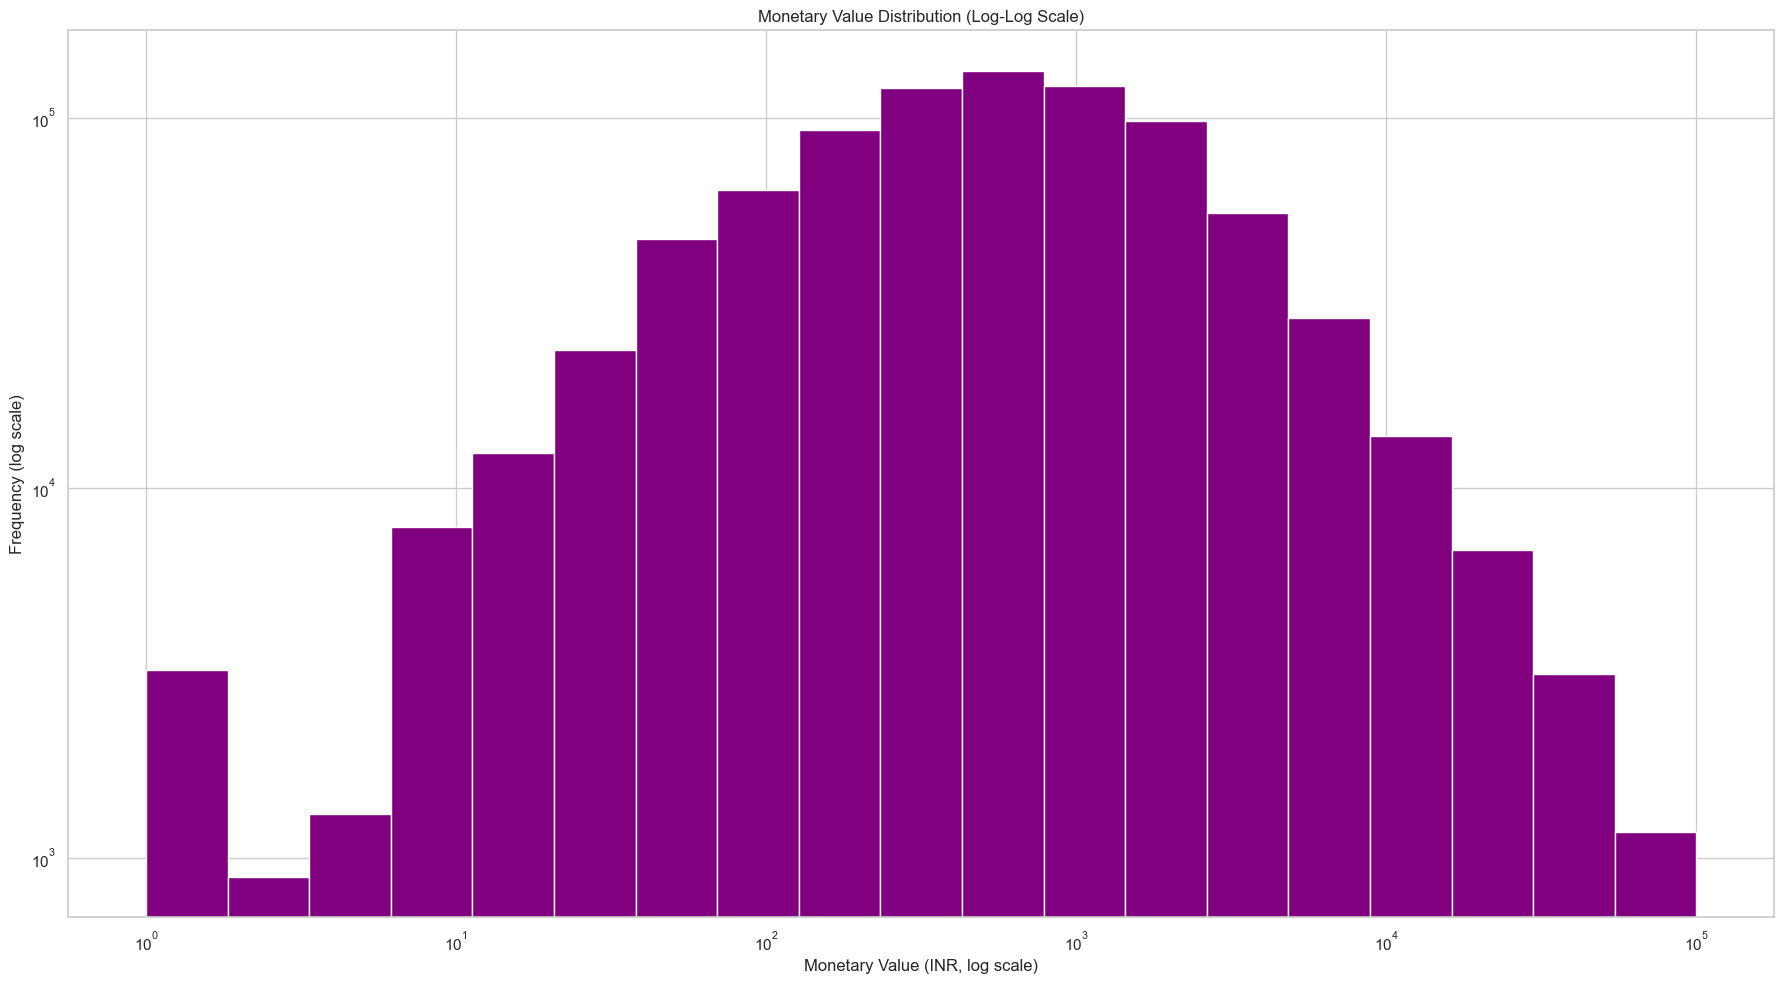

In [60]:
#plotting the monetary values with a more fitting scale (log).
plt.figure(figsize=(18, 10))
plt.hist(rfm['Monetary'], bins=np.logspace(0, 5, 20), color='purple')
plt.title('Monetary Value Distribution (Log-Log Scale)')
plt.xlabel('Monetary Value (INR, log scale)')
plt.ylabel('Frequency (log scale)')
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()

- Now this plot reveals that most customers fall into middle or lower spending ranges.
- There are few _very high_ spenders, but they exist and stand out due to the log scaling.

In [61]:
rfm.corr() #checking fot any unusual correlations between each feature.

,TransactionDate,Recency,Frequency,Monetary
TransactionDate,1.000000,-1.000000,0.218252,0.018711
Recency,-1.000000,1.000000,-0.218252,-0.018711
Frequency,0.218252,-0.218252,1.000000,0.093956
Monetary,0.018711,-0.018711,0.093956,1.000000


✨ The strong inverse correlation between Transaction Data and Recency makes sense, since the more recent a transaction is, the higher (farther away) the Transaction Date is.

#### RFM SCORE
This is assigned/calculated for each customer to determine the high value customers.

In [62]:
#calculating quantiles for each feature, to help set boundaries and understand the data more for analysis.

quantile = rfm[['Recency', 'Frequency', 'Monetary']].quantile(q = [0.25, 0.5, 0.75]).to_dict()

quantile #viewing

{'Recency': {0.25: 43.0, 0.5: 55.0, 0.75: 68.0},
 'Frequency': {0.25: 1.0, 0.5: 1.0, 0.75: 1.0},
 'Monetary': {0.25: 199.0, 0.5: 500.0, 0.75: 1420.0}}

##### The frequency values show that most customers only purchased once. Which will be an issue when assigning frequency scores because the data is skewed.

In [63]:
rfm['Frequency'].value_counts()

Frequency
1    709823
2    113009
3     14263
4      1352
5       108
6         6
Name: count, dtype: int64

In [64]:
#defining function to assign recency score using quartiles.
def assign_R_score(x, feature):
    if x <= quantile[feature][0.25]:
        return 4
    elif x <= quantile[feature][0.5]:
        return 3
    elif x <= quantile[feature][0.75]:
        return 2
    else:
        return 1

#defining function to assign monetary score using quartiles.
def assign_M_score(x, feature):
    if x <= quantile[feature][0.25]:
        return 1
    elif x <= quantile[feature][0.5]:
        return 2
    elif x <= quantile[feature][0.75]:
        return 3
    else:
        return 4

#defining function to assign frequency score with custom rule due to the presence of mostly "1" frequency values.
def custom_frequency_score(x):
    if x <= 3:
        return x
    else:
        return 4


In [65]:
#applying recency scoring to the DataFrame
rfm["R_score"] = rfm["Recency"].apply(lambda x: assign_R_score(x, "Recency"))

#applying custom frequency scoring to the DataFrame
rfm["F_score"] = rfm["Frequency"].apply(custom_frequency_score)

#applying monetary scoring to the DataFrame
rfm["M_score"] = rfm["Monetary"].apply(lambda x: assign_M_score(x, "Monetary"))

rfm

,TransactionDate,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,,
C1010011,2016-09-26,25,2,5106.0,4,2,4
C1010012,2016-08-14,68,1,1499.0,2,1,4
C1010014,2016-08-07,75,2,1455.0,1,2,4
C1010018,2016-09-15,36,1,30.0,4,1,1
C1010024,2016-08-18,64,1,5000.0,2,1,4
...,...,...,...,...,...,...,...
C9099836,2016-08-07,75,1,691.0,1,1,3
C9099877,2016-09-15,36,1,222.0,4,1,2
C9099919,2016-08-18,64,1,126.0,2,1,1


In [66]:
#calculating total RFM Score

rfm['RFM_Score'] = (
    rfm['R_score'] + 
    rfm['F_score'] + 
    rfm['M_score']
)

rfm.head()

,TransactionDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,,
C1010011,2016-09-26,25,2,5106.0,4,2,4,10
C1010012,2016-08-14,68,1,1499.0,2,1,4,7
C1010014,2016-08-07,75,2,1455.0,1,2,4,7
C1010018,2016-09-15,36,1,30.0,4,1,1,6
C1010024,2016-08-18,64,1,5000.0,2,1,4,7


#### Creating RFM groups.
✨ RFM Groups combine the recency, frequency, and monetary scores into a single string label (like '432') this label is helping segment customers into clear behavioral patterns. For example, '555' is meaning best recency, best frequency, best monetary (top customers). It allows quick filtering and grouping of similar customer types for targeted actions marketers and analysts are using it to design focused campaigns, retention plans, or loyalty programs.


In [67]:
#creating rfm group by combining R, F, and M scores into one string group label
rfm['RFM_Group'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,TransactionDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Group
CustomerID,,,,,,,,,
C1010011,2016-09-26,25,2,5106.0,4,2,4,10,424
C1010012,2016-08-14,68,1,1499.0,2,1,4,7,214
C1010014,2016-08-07,75,2,1455.0,1,2,4,7,124
C1010018,2016-09-15,36,1,30.0,4,1,1,6,411
C1010024,2016-08-18,64,1,5000.0,2,1,4,7,214


#### 💡 The highest RFM score would be 12, if a customer gets a score of 4 in each aspect, likewise, a group of 444 would show a high value customer.

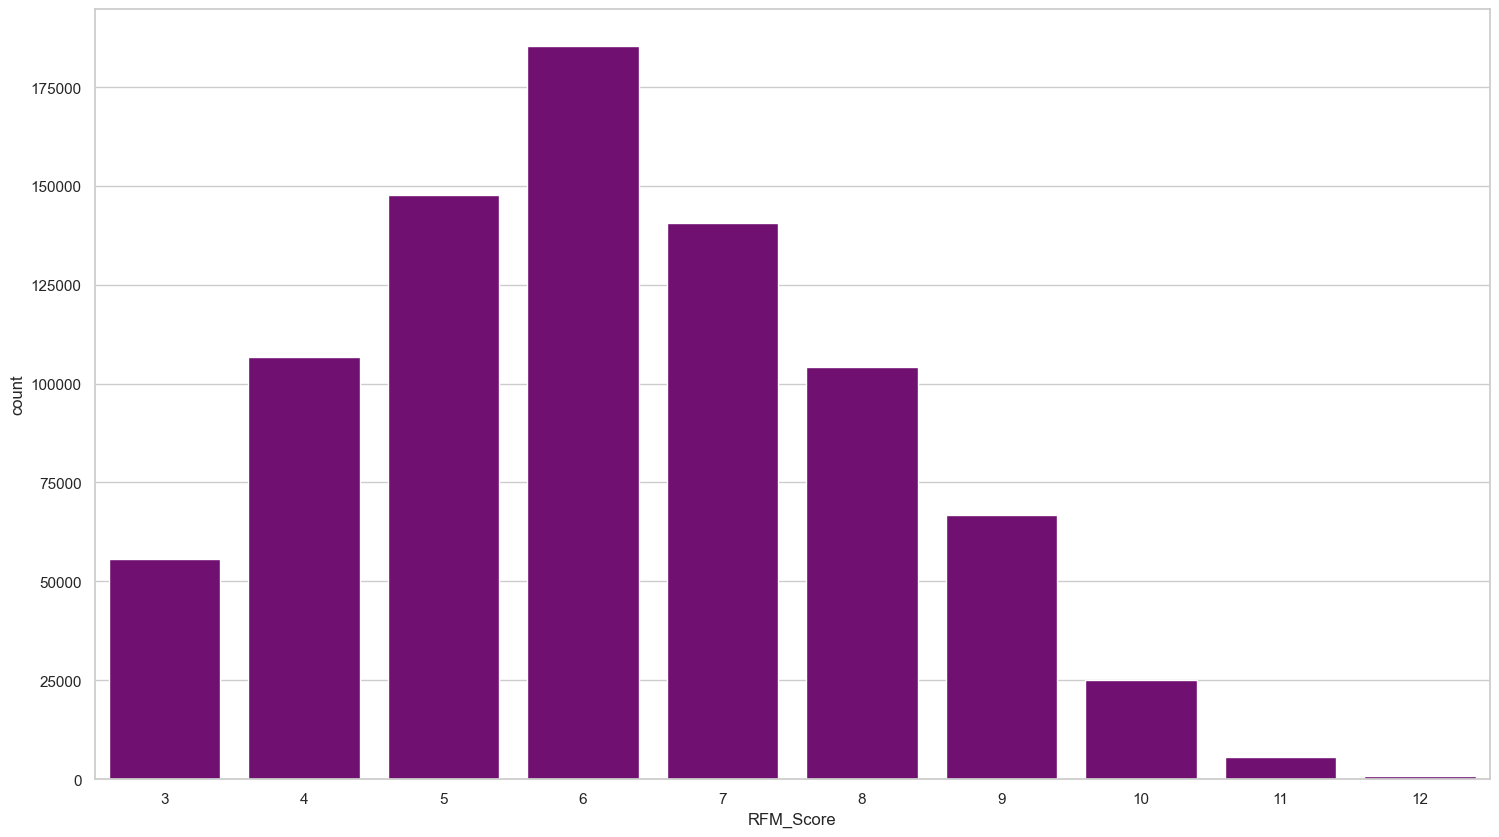

In [70]:
#visualising the RFM scores to determine what customers are high value

plt.figure(figsize = (18, 10))
sns.countplot(x = rfm['RFM_Score'], color = 'purple')

plt.show()

Using the plot, defining the classification of customers:
- **3 - 5** - Low-value customers : Customers which have the highest chance of churning.
- **6 - 9** - Medium-value customers
- **10 - 12** - High value customers : Customers that have the lowest chances of churning.

##### Segmenting the customers based on these defined classes.

In [73]:
#creating a function to segment customers into value classes/

def segment_customers(score):
    if score <= 5:
        return "Low"
    elif score <= 9:
        return "Medium"
    else:
        return "High"

In [74]:
rfm["Segments"] = rfm['RFM_Score'].apply(lambda score: segment_customers(score)) #applying the function.

In [75]:
rfm.head() #viewing the df

,TransactionDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Group,Segments
CustomerID,,,,,,,,,,
C1010011,2016-09-26,25,2,5106.0,4,2,4,10,424,High
C1010012,2016-08-14,68,1,1499.0,2,1,4,7,214,Medium
C1010014,2016-08-07,75,2,1455.0,1,2,4,7,124,Medium
C1010018,2016-09-15,36,1,30.0,4,1,1,6,411,Medium
C1010024,2016-08-18,64,1,5000.0,2,1,4,7,214,Medium


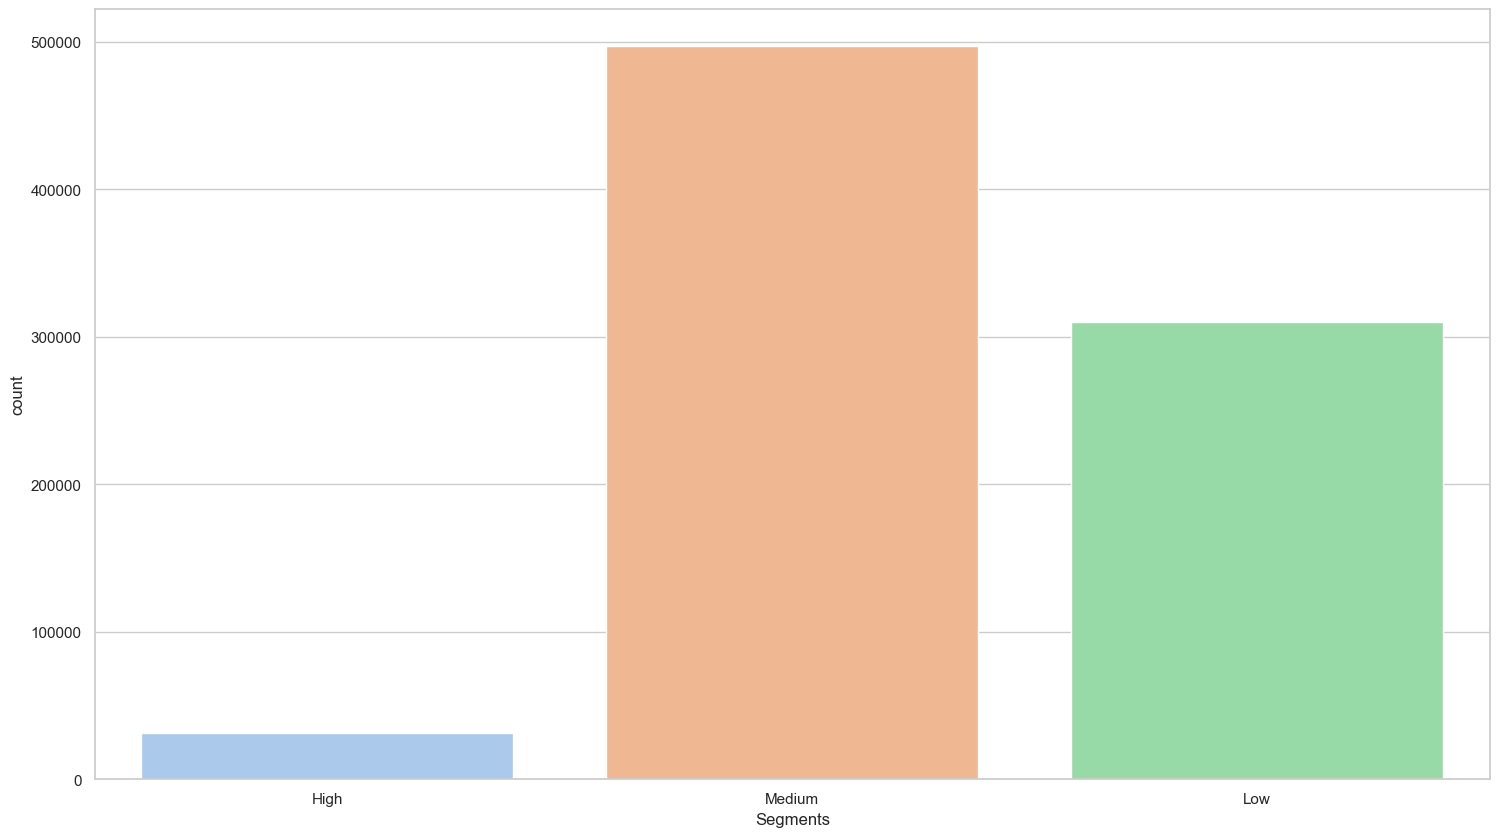

In [82]:
#visualising the segments

plt.figure(figsize = (18, 10))
sns.set_palette("pastel") #setting color and hue for differently colored bars, so we can observe the segments more easily.
sns.countplot(x=rfm['Segments'], hue=rfm['Segments'])

plt.show()

##### 💡 To give more importance to customer recency, we can create a weighted RFM score. This is useful because the time span of the data may be too short to reliably capture each customer’s _true_ monetary value and frequency of transactions over a longer/different period. So, in this case the aim is to retain the most recent customers, and they are being prioritised over frequency and monetary.

In [159]:
#checking the recency values of the low value customers to determine whether to class them as churned customers or not.
rfm[rfm['Segments'] == 'Low']['Recency'].value_counts()

Recency
75    14086
69    14034
76    13905
70    12576
73    12110
71    12104
72    11891
74    11784
77    11379
80    11360
78    11185
81    11122
79    11113
61     8431
68     8267
67     8185
66     8121
65     8068
60     7800
62     7798
64     7692
63     7606
57     7553
59     7233
58     7224
56     7138
48     4473
44     4416
49     4369
50     4361
47     4242
51     4185
45     4164
55     4140
46     4092
52     3939
53     3935
54     3832
Name: count, dtype: int64

##### 💡 The values reveal that the highest number of days since the customers have perfomed transactions is 75 days, which is less than three months, so I would not class them as churned. The segments would remain Low, Medium and High value.

#### ASSIGNING HIGHER VALUE TO (A) CERTAIN METRIC VIA WEIGHTED RFM SCORE.

In [84]:
#creating weighted RFM score

rfm['Weighted Score'] = ((rfm['R_score']*2) + (rfm['F_score']) + (rfm['M_score']))

rfm.head()

,TransactionDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Group,Segments,Weighted Score
CustomerID,,,,,,,,,,,
C1010011,2016-09-26,25,2,5106.0,4,2,4,10,424,High,14
C1010012,2016-08-14,68,1,1499.0,2,1,4,7,214,Medium,9
C1010014,2016-08-07,75,2,1455.0,1,2,4,7,124,Medium,8
C1010018,2016-09-15,36,1,30.0,4,1,1,6,411,Medium,10
C1010024,2016-08-18,64,1,5000.0,2,1,4,7,214,Medium,9


✅ Now, these are adjusted scores based on BankTrust's priority/current needs. If these needs change, the criteria for the weighted score should also change. The new scores will be visualised below.

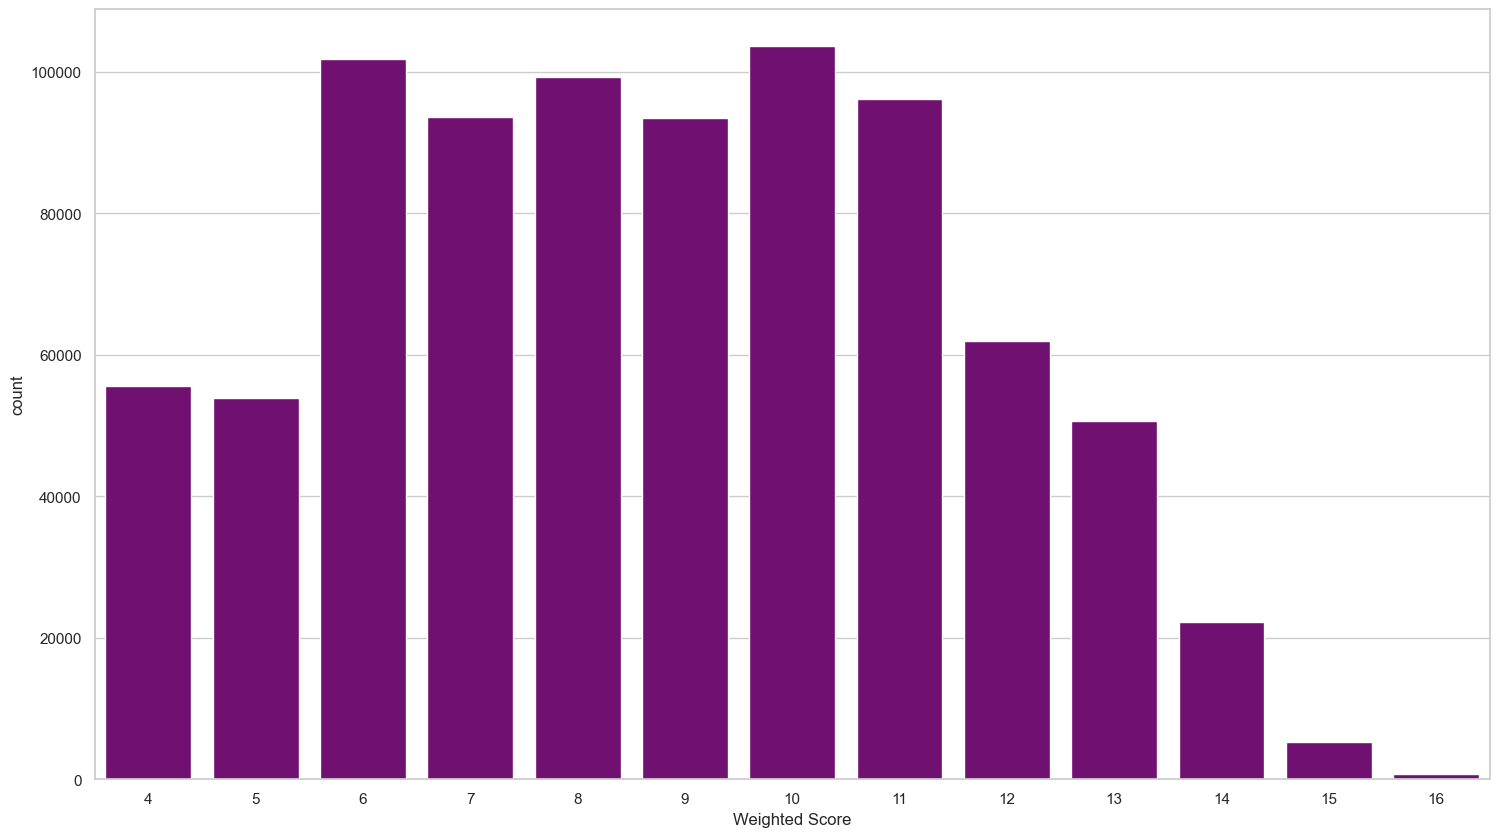

In [85]:
#visualising the weighted scores to compare

plt.figure(figsize = (18, 10))
sns.countplot(x = rfm['Weighted Score'], color = 'purple')

plt.show()

There is a wider range of scores. Creating segments from these new weighted scores using the function defined earlier.

In [86]:
rfm["Weighted Segments"] = rfm['Weighted Score'].apply(lambda score: segment_customers(score)) #applying the function.

rfm.head()

,TransactionDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Group,Segments,Weighted Score,Weighted Segments
CustomerID,,,,,,,,,,,,
C1010011,2016-09-26,25,2,5106.0,4,2,4,10,424,High,14,High
C1010012,2016-08-14,68,1,1499.0,2,1,4,7,214,Medium,9,Medium
C1010014,2016-08-07,75,2,1455.0,1,2,4,7,124,Medium,8,Medium
C1010018,2016-09-15,36,1,30.0,4,1,1,6,411,Medium,10,High
C1010024,2016-08-18,64,1,5000.0,2,1,4,7,214,Medium,9,Medium


There are now differences in the "Segments" and "Weighted Segments" because Recency is being prioritised. Some customers' values have changed.

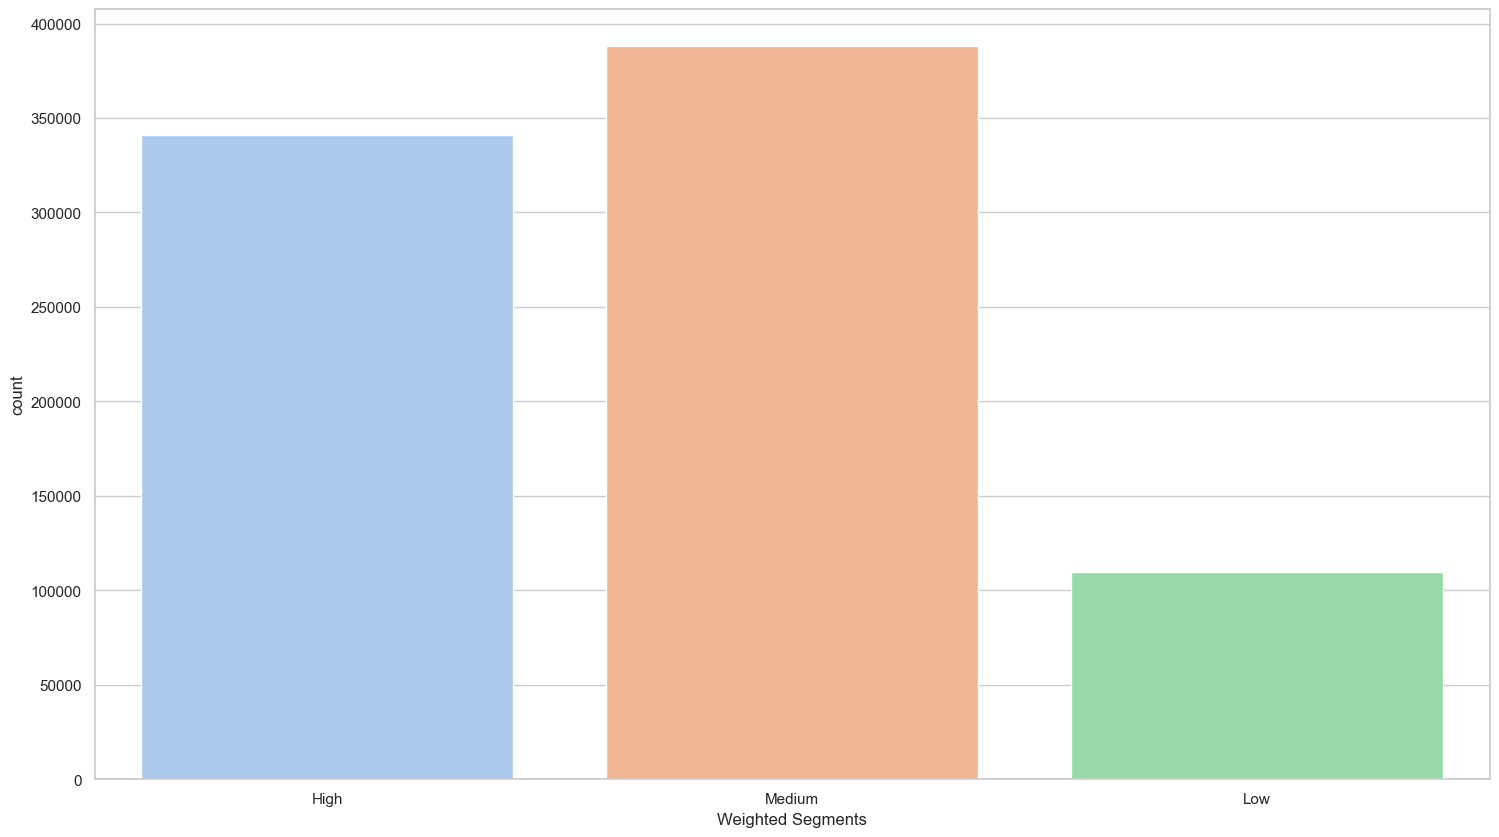

In [87]:
#visualising the weighted segments

plt.figure(figsize = (18, 10))
sns.set_palette("pastel") #setting color and hue for differently colored bars, so we can observe the segments more easily.
sns.countplot(x=rfm['Weighted Segments'], hue=rfm['Weighted Segments'])

plt.show()

✨ The medium-value customers are still the most even when recency is prioritised. However, the number of high value customers have increased and the number of low-value customers have dropped.

## 🧩 CLUSTERING.

#### Using an unsupervised learning technique (K-Means) for further customer segmentation.

In [93]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 838561 entries, C1010011 to C9099956
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   TransactionDate    838561 non-null  datetime64[ns]
 1   Recency            838561 non-null  int64         
 2   Frequency          838561 non-null  int64         
 3   Monetary           838561 non-null  float64       
 4   R_score            838561 non-null  int64         
 5   F_score            838561 non-null  int64         
 6   M_score            838561 non-null  int64         
 7   RFM_Score          838561 non-null  int64         
 8   RFM_Group          838561 non-null  object        
 9   Segments           838561 non-null  object        
 10  Weighted Score     838561 non-null  int64         
 11  Weighted Segments  838561 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(7), object(3)
memory usage: 115.4+ MB


In [95]:
#selecting columns for the clustering using the RFM components and their scores.

rfm_features = rfm.drop(['TransactionDate','RFM_Group', 'Segments', 'Weighted Score', 'Weighted Segments'], axis=1)

rfm_features.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
C1010011,25,2,5106.0,4,2,4,10
C1010012,68,1,1499.0,2,1,4,7
C1010014,75,2,1455.0,1,2,4,7
C1010018,36,1,30.0,4,1,1,6
C1010024,64,1,5000.0,2,1,4,7


#### _Scale dataframe_
Why?
- KMeans uses Euclidean distance to group points.
- If one feature has much larger numeric values (e.g., Monetary in thousands vs. R_score in single digits), it dominates the distance, making the clustering biased.
- Scaling (e.g., with StandardScaler or MinMaxScaler) puts all features on **the same scale**, so no one feature unfairly outweighs the others.

In [98]:
#scaling the data before clustering, using standardscaler

scaler = StandardScaler()

In [99]:
scaled_df = scaler.fit_transform(rfm_features)

scaled_df

array([[-1.99784226,  1.89850476,  0.50815942, ...,  1.90370043,
         1.34298086,  2.0981349 ],
       [ 0.82740076, -0.40040305, -0.03103654, ..., -0.40109946,
         1.34298086,  0.44852541],
       [ 1.28732404,  1.89850476, -0.03761393, ...,  1.90370043,
         1.34298086,  0.44852541],
       ...,
       [ 0.56458745, -0.40040305, -0.23628081, ..., -0.40109946,
        -1.33617244, -1.20108408],
       [-0.09244581, -0.40040305, -0.24764174, ..., -0.40109946,
        -1.33617244, -0.65121425],
       [-1.93213894, -0.40040305, -0.12730552, ..., -0.40109946,
         0.44992976,  0.99839524]], shape=(838561, 7))

#### 💪 ELBOW METHOD TO DETERMINE NUMBER OF OPTIMAL CLUSTERS.

In [102]:
kmeans = KMeans(random_state = 42)

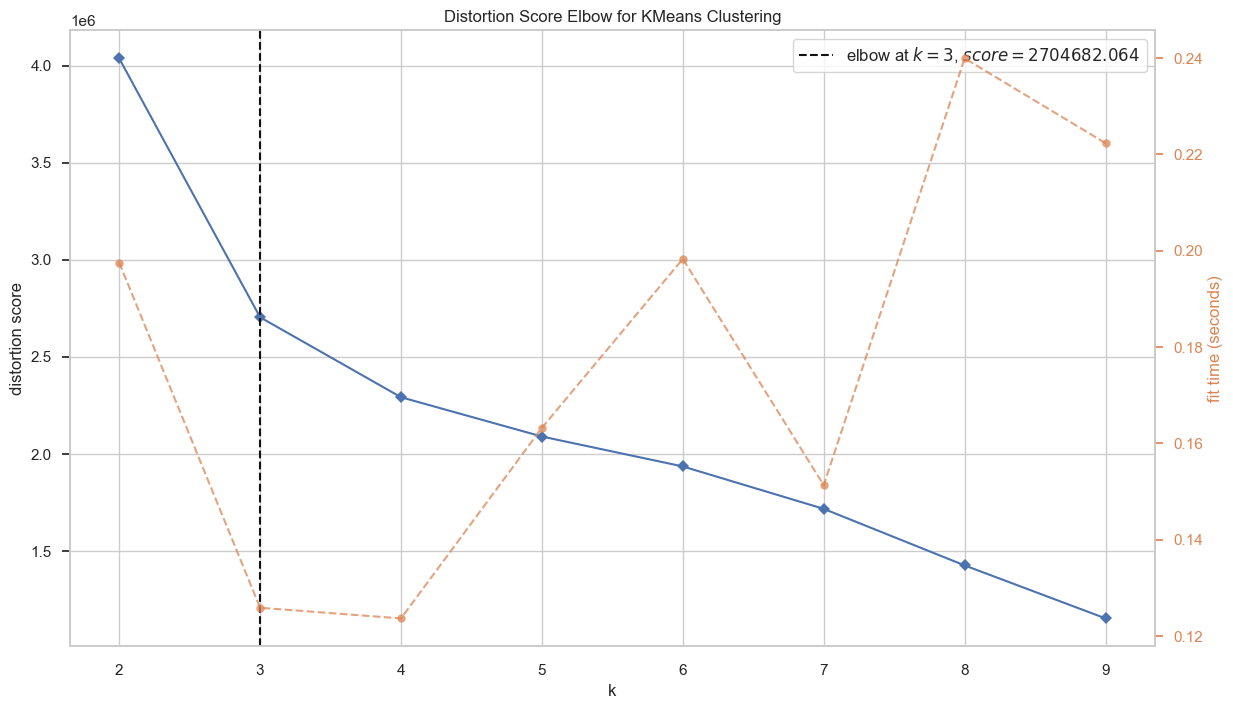

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [103]:
#applying the elbow visualizer to find optimal k
visualizer = KElbowVisualizer(kmeans, k=(2, 10), metric='distortion', timing=False)

visualizer.fit(scaled_df)  #fitting the scaled data
visualizer.show()         #showing the elbow plot

##### _Optimal k=3_

#### _Checking with Calinski-Harabasz metric as well._

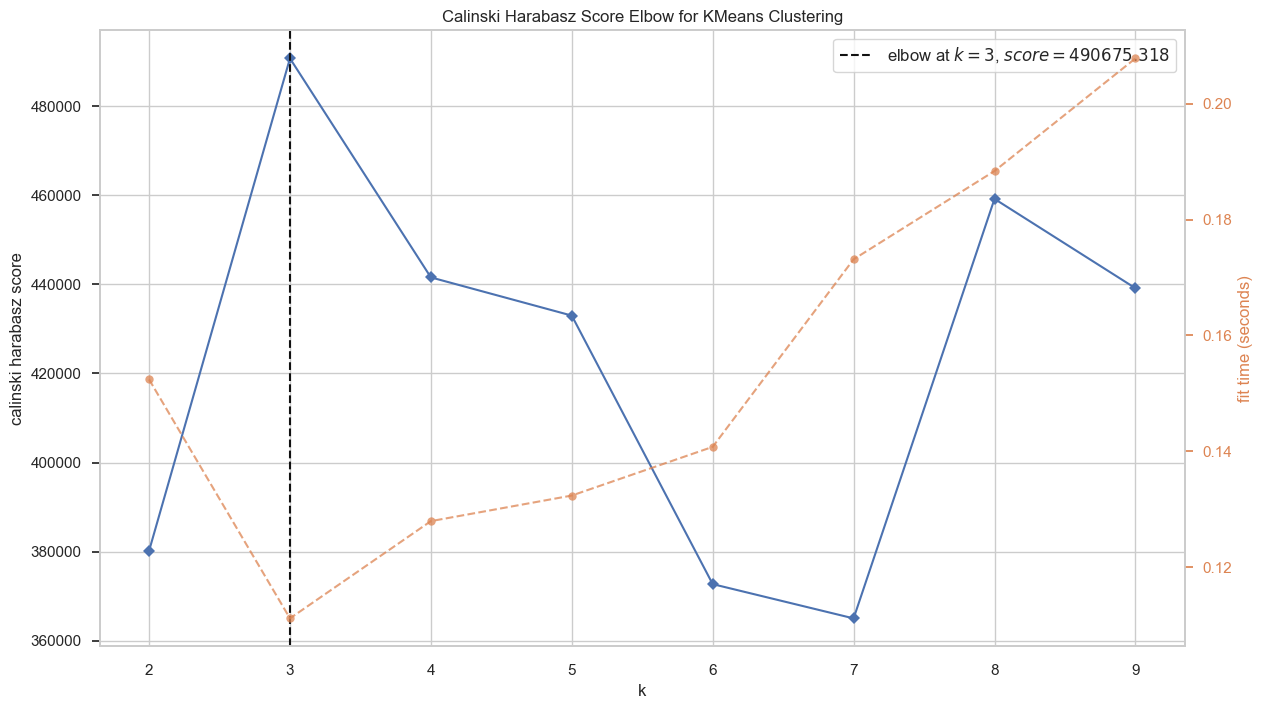

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [107]:
#using KElbowVisualizer with Calinski-Harabasz metric
visualizer_2 = KElbowVisualizer(kmeans, k=(2, 10), metric='calinski_harabasz', timing= False)

visualizer_2.fit(scaled_df)  #fitting the scaled data
visualizer_2.show() 

##### _Optimal k=3 again_

#### _Checking with another method (manual) as well._

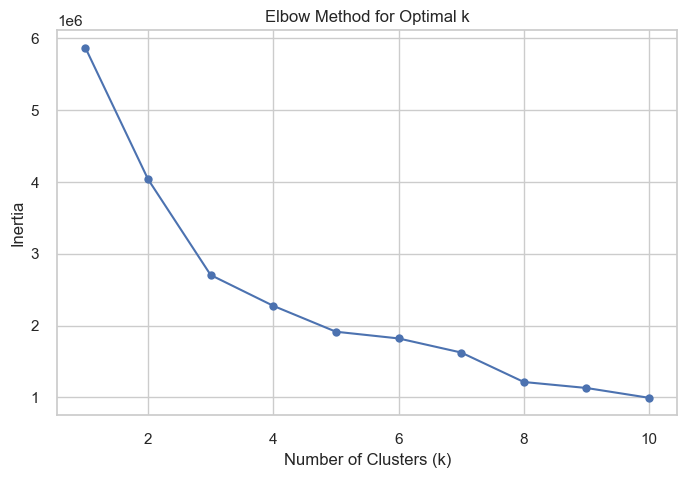

In [104]:
#list to store inertia values
inertia = []

#testing k values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

#plotting the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

##### _Optimal k=3 again_

### K-Means

In [108]:
#running KMeans with chosen number of clusters
k = 3  # replace with your optimal k
model = KMeans(n_clusters=k, random_state=42)

model.fit(scaled_df)

KMeans(n_clusters=3, random_state=42)

In [111]:
#getting clusters labels using .labels_
rfm_features['Cluster'] = model.labels_

rfm_features['Cluster']

CustomerID
C1010011    2
C1010012    1
C1010014    2
C1010018    0
C1010024    1
           ..
C9099836    1
C9099877    0
C9099919    1
C9099941    0
C9099956    0
Name: Cluster, Length: 838561, dtype: int32

In [112]:
rfm_features

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Cluster
CustomerID,,,,,,,,
C1010011,25,2,5106.0,4,2,4,10,2
C1010012,68,1,1499.0,2,1,4,7,1
C1010014,75,2,1455.0,1,2,4,7,2
C1010018,36,1,30.0,4,1,1,6,0
C1010024,64,1,5000.0,2,1,4,7,1
...,...,...,...,...,...,...,...,...
C9099836,75,1,691.0,1,1,3,5,1
C9099877,36,1,222.0,4,1,2,7,0
C9099919,64,1,126.0,2,1,1,4,1


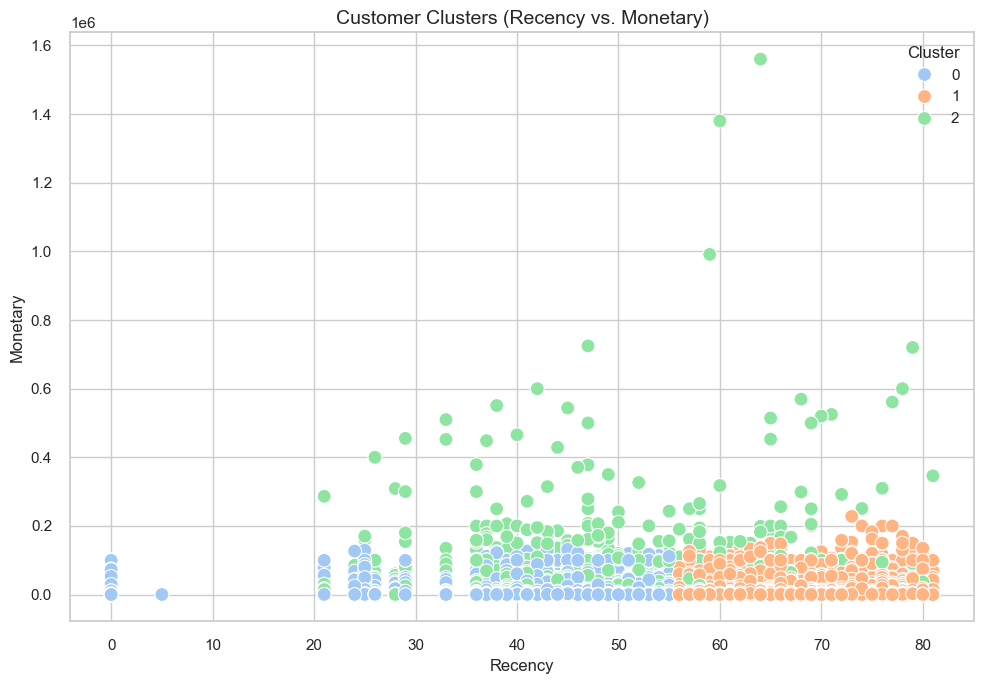

In [116]:
#plotting clusters using two features
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=rfm_features,
    x='Recency',           
    y='Monetary',          
    hue=rfm_features['Cluster'],         # cluster labels
    palette='pastel',
    s=100
)

plt.title('Customer Clusters (Recency vs. Monetary)', fontsize=14)
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

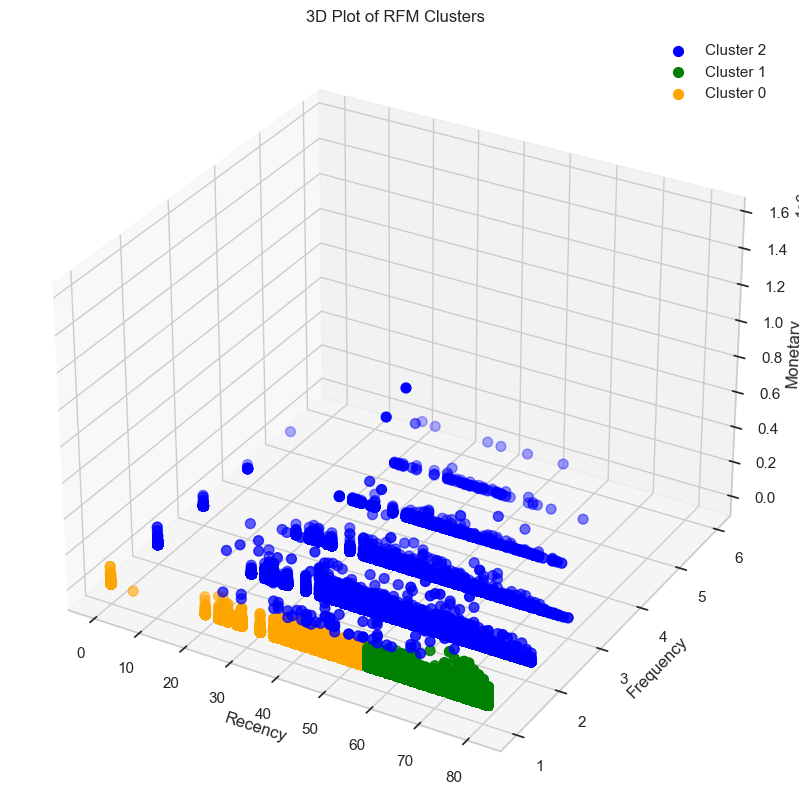

In [122]:
fig = plt.figure(figsize=(10, 10))  #creating the figure
ax = fig.add_subplot(111, projection="3d")  #adding a 3D subplot

colors = ['blue', 'green', 'orange']  #defining colors for clusters (expand if you have more clusters)

for cluster, color in zip(rfm_features['Cluster'].unique(), colors):  #looping over each cluster and its color
    cluster_data = rfm_features[rfm_features['Cluster'] == cluster]  #selecting data for the current cluster
    ax.scatter(
        cluster_data["Recency"],
        cluster_data["Frequency"],
        cluster_data["Monetary"],
        c=color,
        s=50,
        marker='o',
        label=f"Cluster {cluster}"
    )

ax.set_xlabel("Recency")  
ax.set_ylabel("Frequency")  
ax.set_zlabel("Monetary")  

ax.legend()  #adding legend for clusters
ax.set_title("3D Plot of RFM Clusters")  #plot title

plt.show()  #displaying the plot

##### Checking how many customers are in each cluster

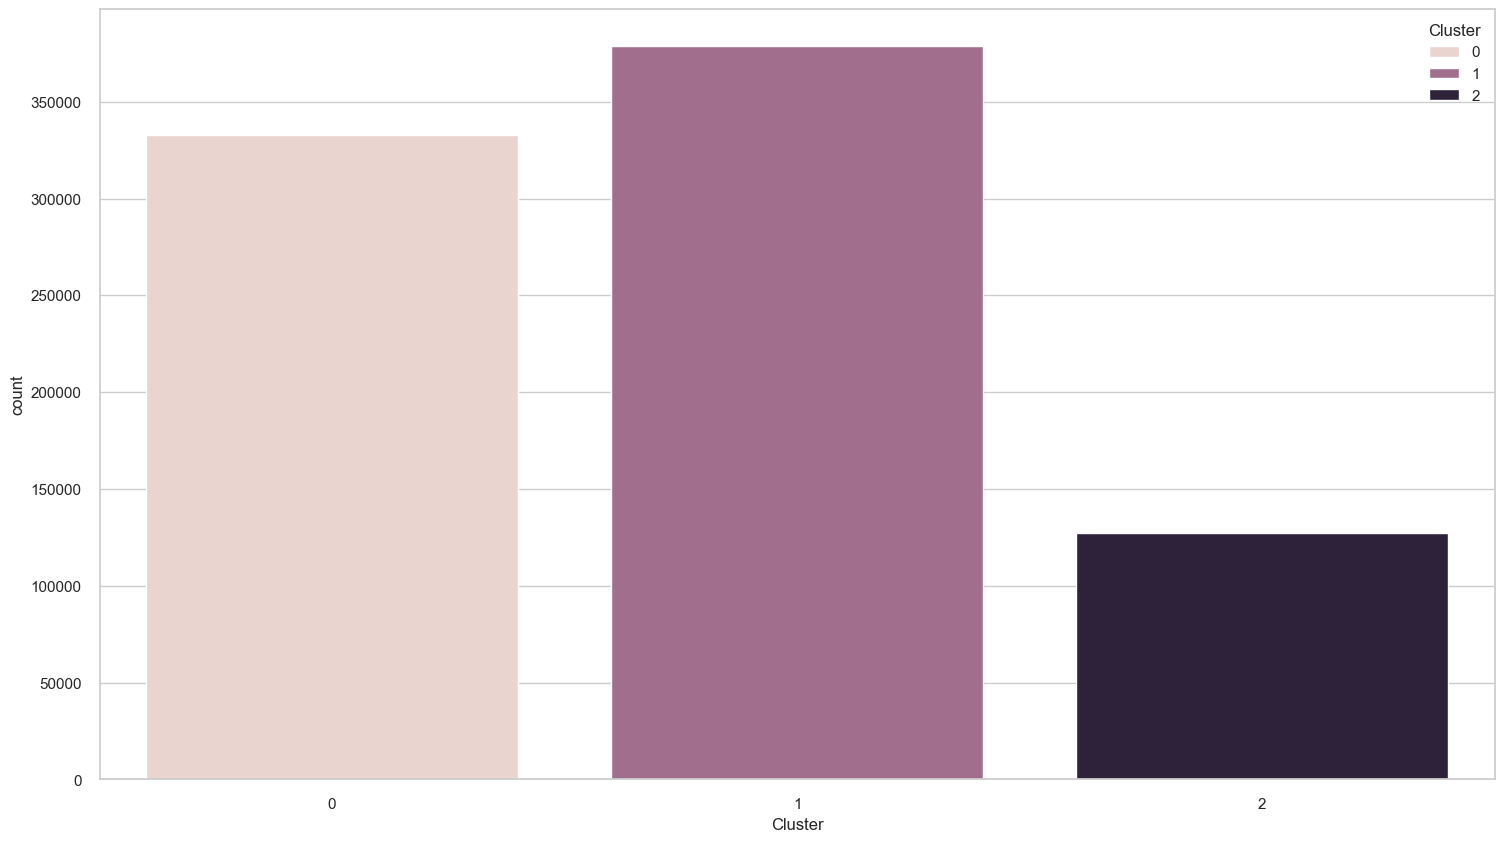

In [120]:
#visualising the weighted segments

plt.figure(figsize = (18, 10))
sns.set_palette("pastel") #setting color and hue for differently colored bars, so we can observe the segments more easily.
sns.countplot(x=rfm_features['Cluster'], hue=rfm_features['Cluster'])

plt.show()

#### Checking stats of each cluster

In [123]:
#looping over each unique cluster and printing its summary stats
for cluster in rfm_features["Cluster"].unique():
    print(f"cluster: {cluster}")
    print(rfm_features[rfm_features["Cluster"] == cluster].describe())

cluster: 2
             Recency      Frequency      Monetary        R_score  \
count  126990.000000  126990.000000  1.269900e+05  126990.000000   
mean       47.284534       2.135633  3.340285e+03       3.103945   
std        12.917054       0.381620  1.304441e+04       0.918014   
min         0.000000       1.000000  2.000000e+00       1.000000   
25%        39.000000       2.000000  6.460000e+02       2.000000   
50%        46.000000       2.000000  1.370000e+03       3.000000   
75%        56.000000       2.000000  2.905000e+03       4.000000   
max        81.000000       6.000000  1.560035e+06       4.000000   

             F_score        M_score      RFM_Score   Cluster  
count  126990.000000  126990.000000  126990.000000  126990.0  
mean        2.134688       3.260556       8.499189       2.0  
std         0.375592       0.859476       1.352616       0.0  
min         1.000000       1.000000       5.000000       2.0  
25%         2.000000       3.000000       8.000000       2.0 

#### 🗂️ Using box plots to view characteristics of each cluster.

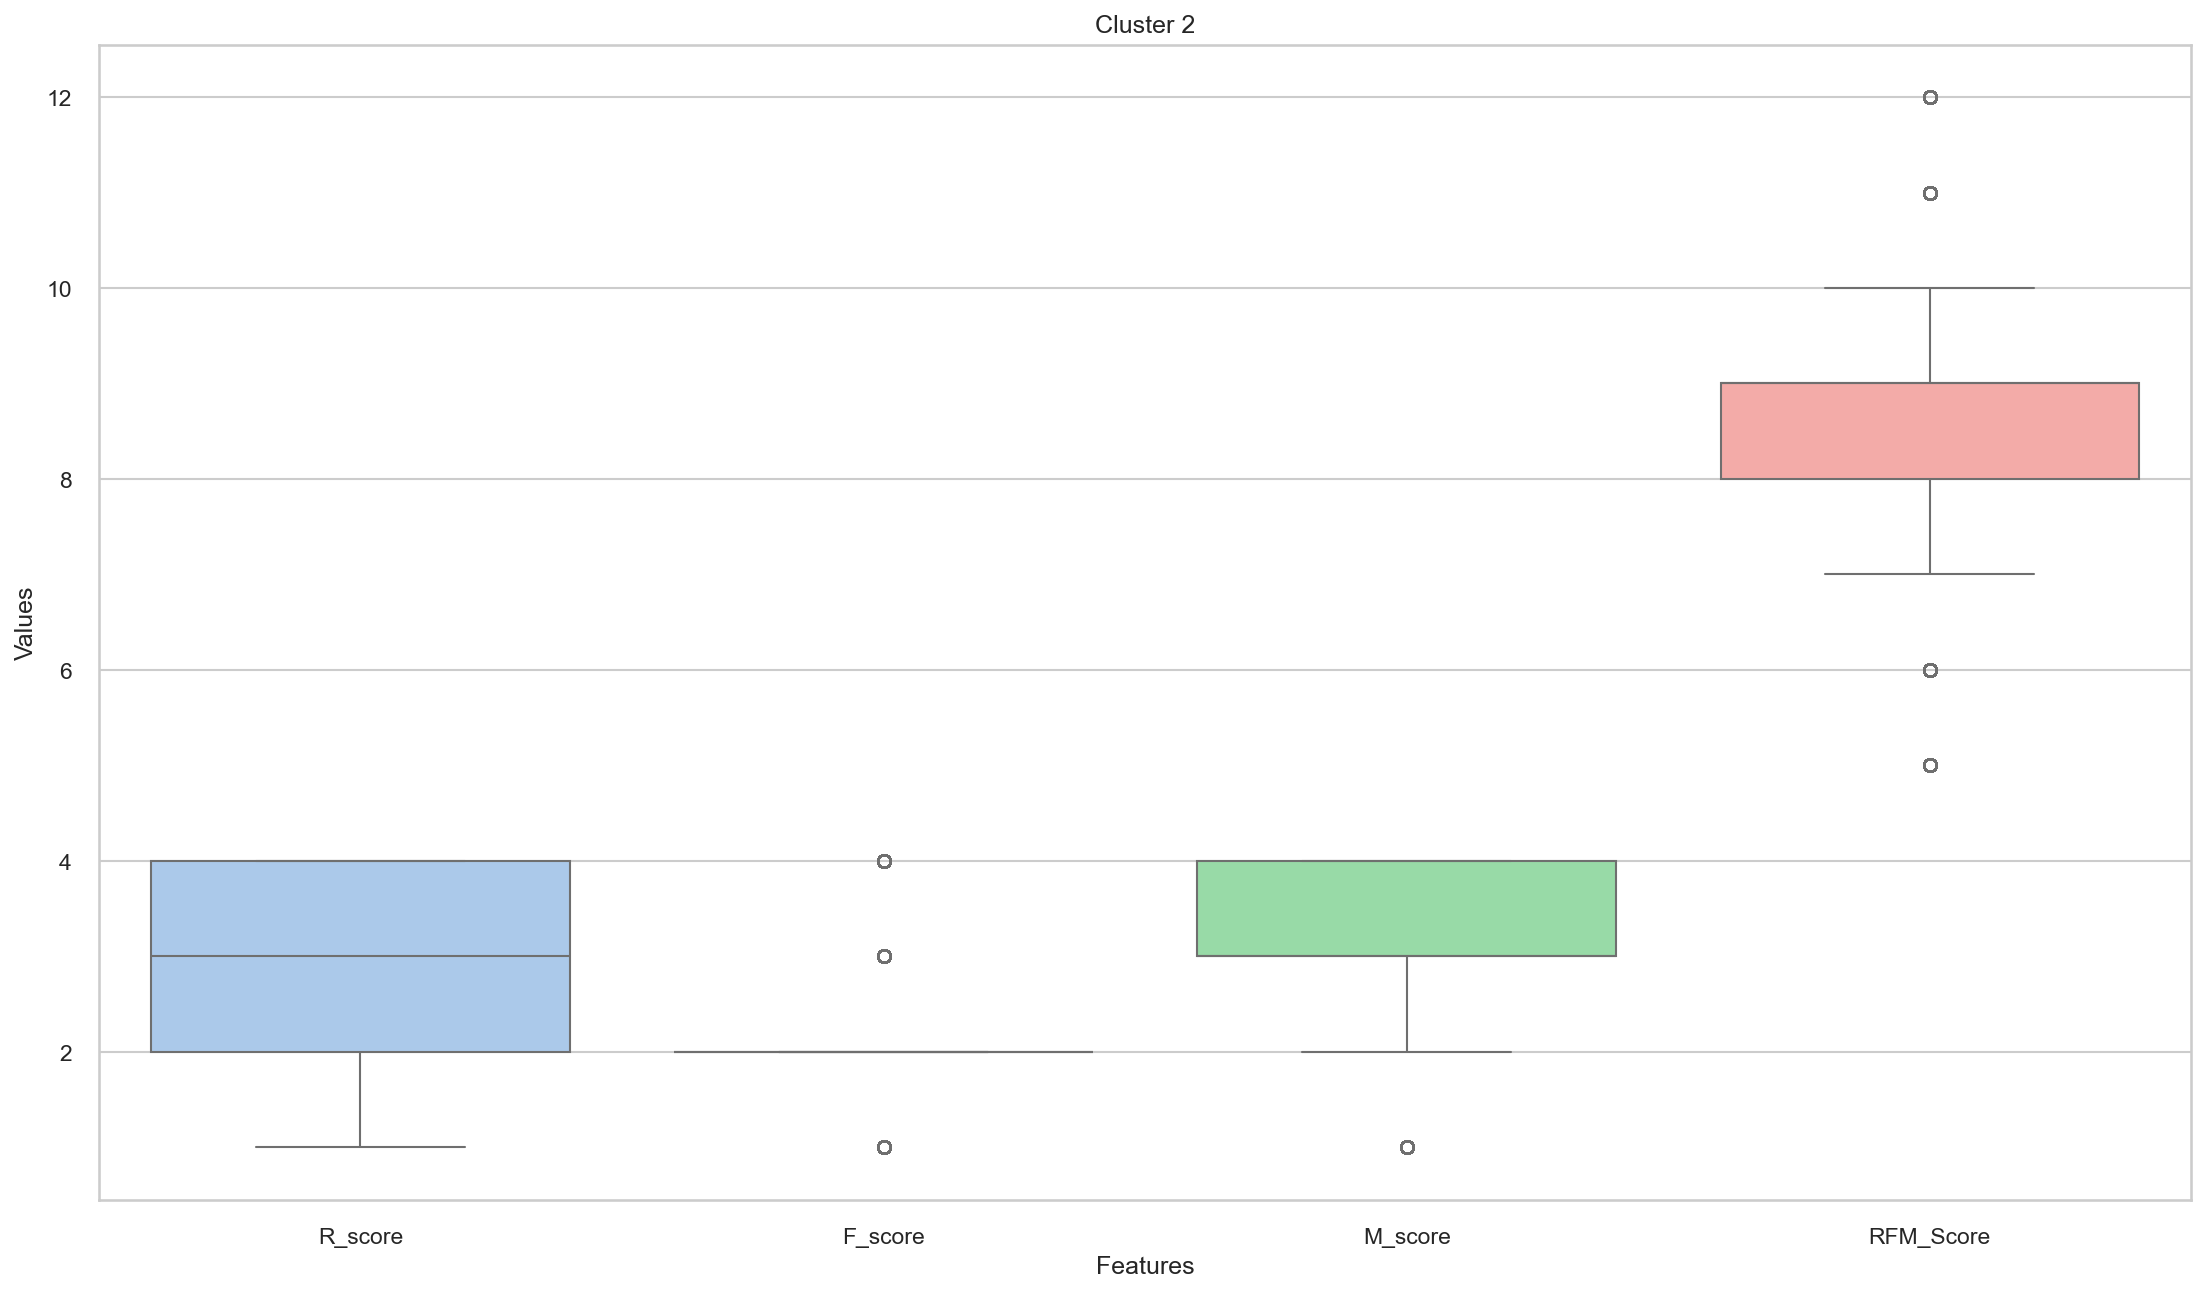

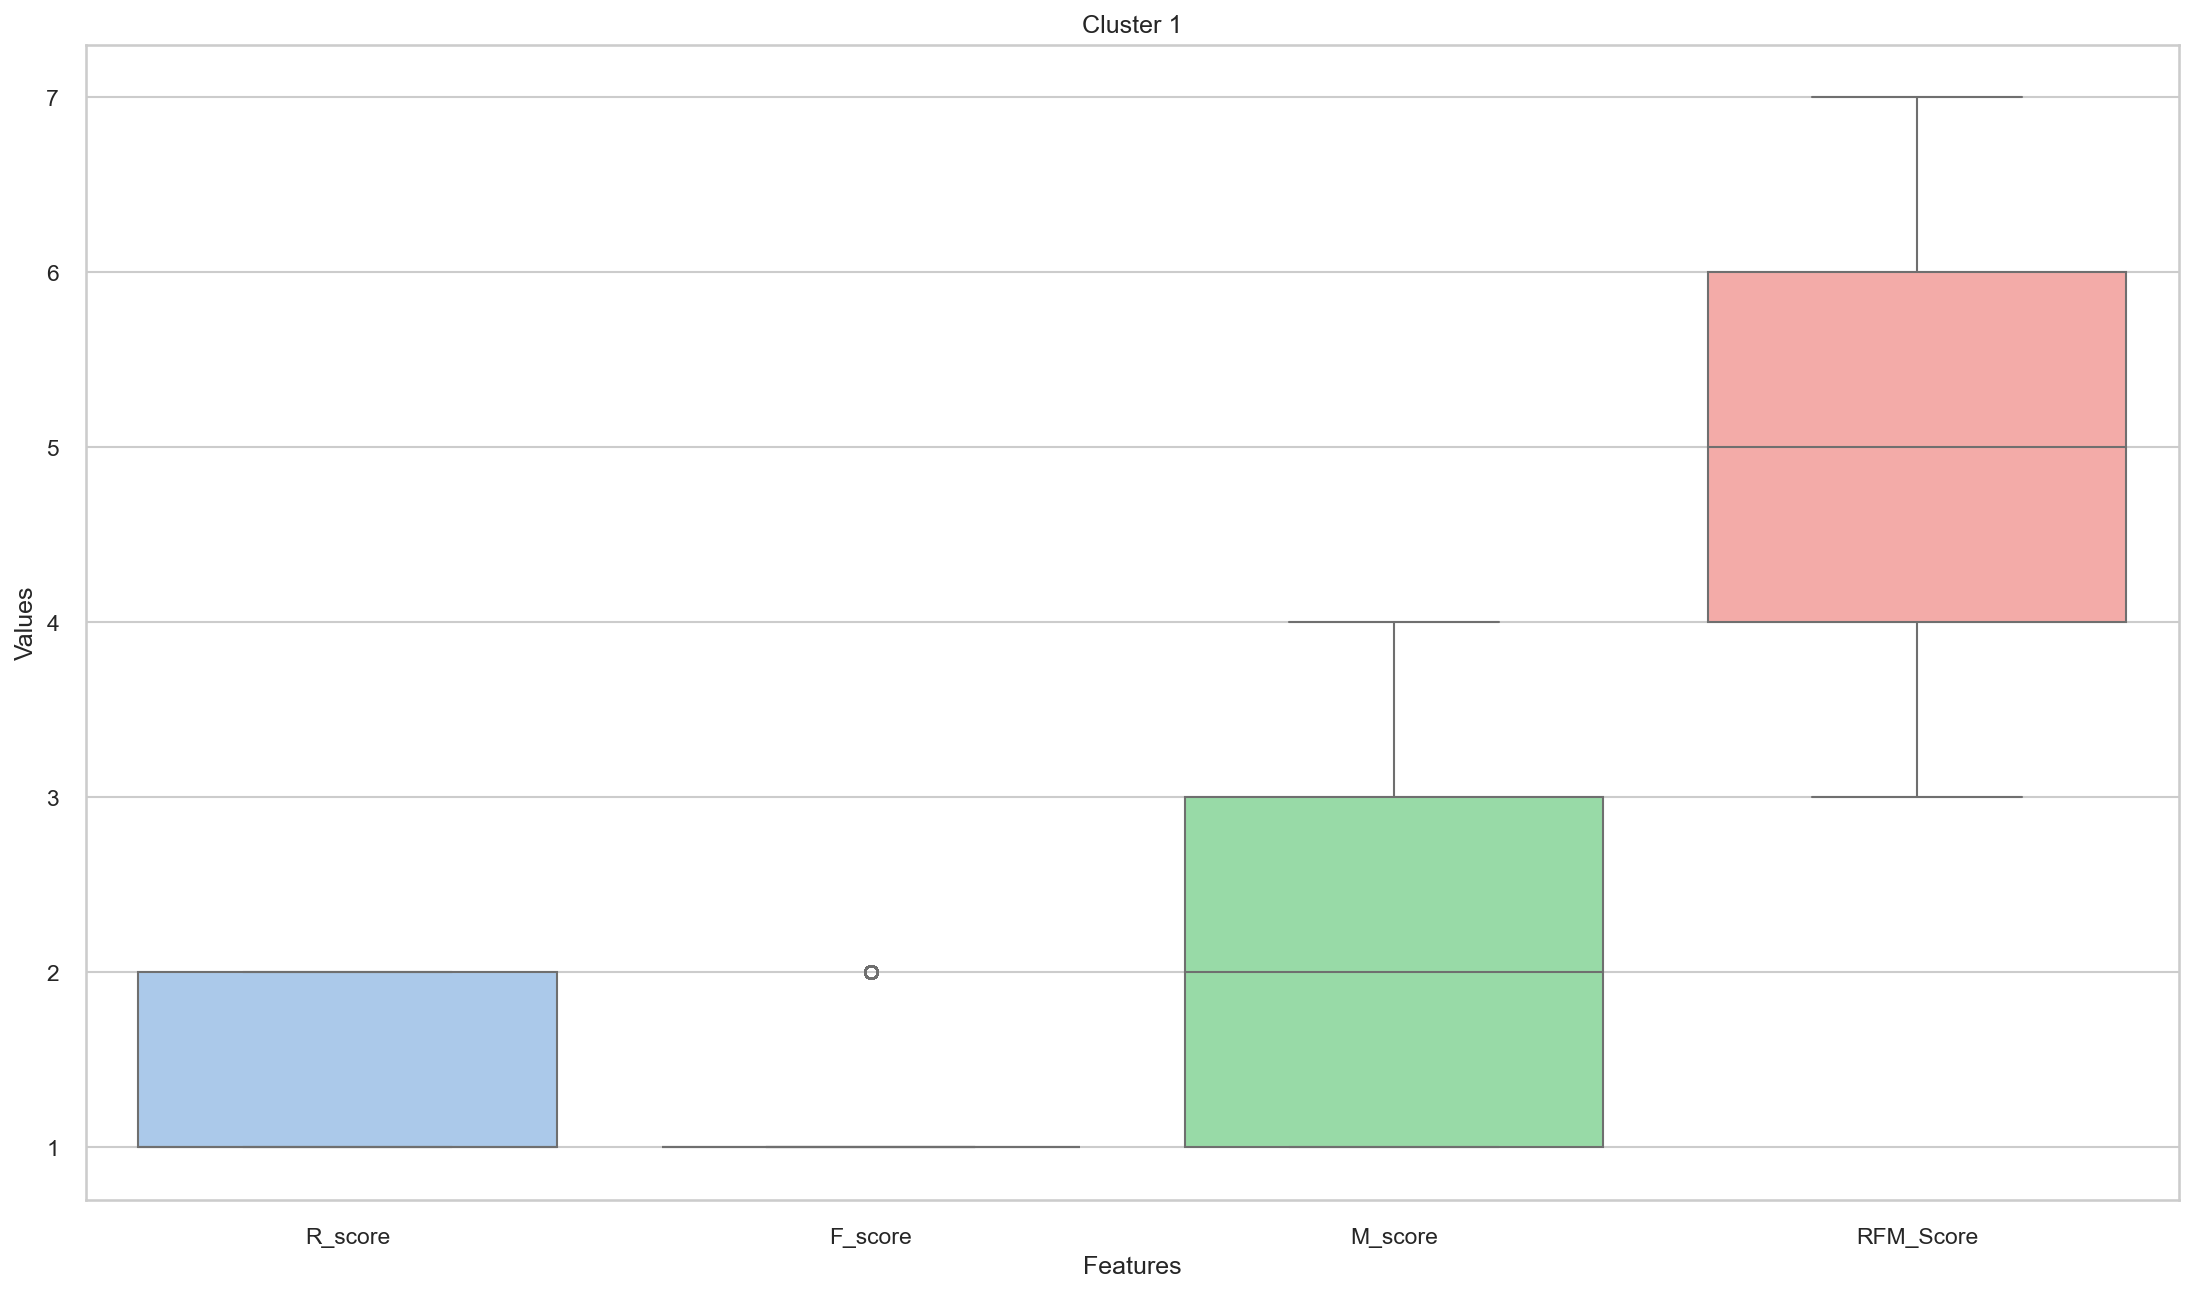

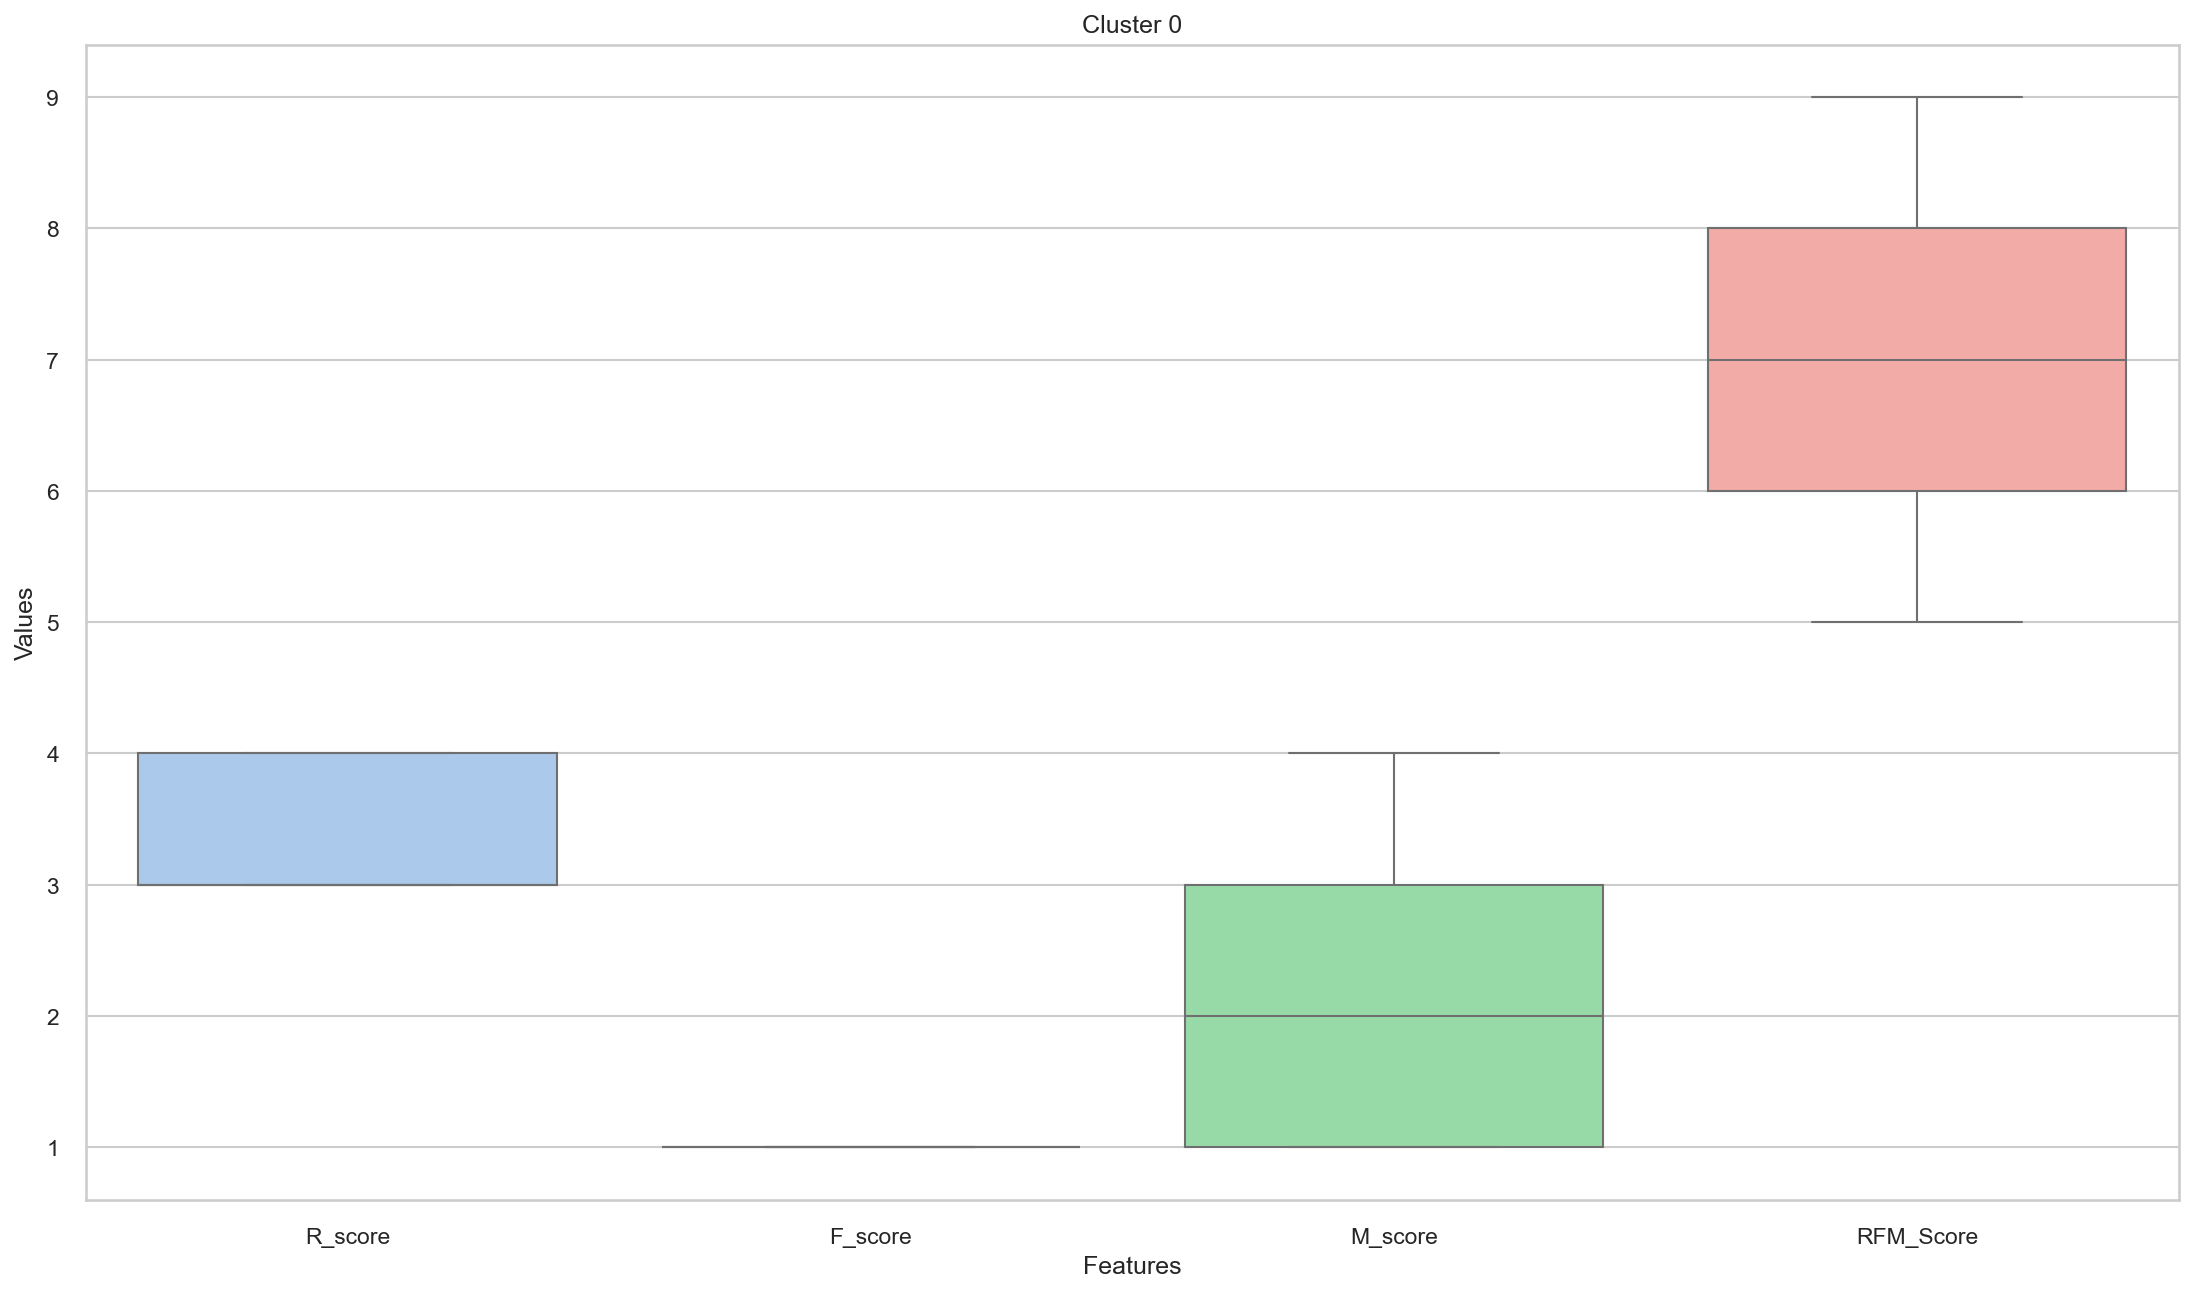

In [128]:
#looping to plot boxplots for each cluster
for cluster in rfm_features["Cluster"].unique():
    cluster_data = rfm_features[rfm_features["Cluster"] == cluster]
    plt.figure(figsize=(18, 10), dpi=150)
    sns.boxplot(data=cluster_data[["R_score", "F_score", "M_score", "RFM_Score"]])
    plt.title(f"Cluster {cluster}")
    plt.ylabel("Values")
    plt.xlabel("Features")
    plt.show()

#### Looking at the box plots, the following characteristics can be observed for each cluster and insights drawn:
**🔶 Cluster 0**:

- Customers have **high recency scores** (_between 3 and 4_), meaning they **have transacted recently**.

- Customers have very **low frequency scores** (all 1).

- Most monetary scores are between 1 and 3, showing **low-medium transaction amounts**, though a few reach 4. Average is 2.

- Most (75%) customers have **RFM scores between 6 and 8**; hinting at medium-value customers.

**🪙 Cluster 1**:

- Customers have **low recency scores** (1–2), meaning they have **not transacted recently**.

- Customers have **low frequency scores** (mostly 1), with a few exceptions scoring 2.

- Half have **low monetary scores** (1–2); the other half score slightly higher (2–3). Average monetary score is 2 (same as Cluster 0).

- Most (75%) customers have **RFM scores between 4 and 6**; hinting at low-value customers.

**💎 Cluster 2**:

- Most customers (75%) have **high recency scores** (2–4), with an average of 3, showing **recent transactions have been performed**.

- Customers have **relatively high frequency scores** (mostly 2), with some 1, 3, and 4 outliers present.

- Most customers have **high monetary scores** (3–4), with a few outliers scoring 1.

- Most customers (75%) have an **RFM scores between 8 and 9**; the rest (25%) score between 7 and 10. These are most likely the high-value customers.



## SAVE DATA

In [160]:
#creating the full df

rfm['Cluster'] = rfm_features["Cluster"]

rfm.head()

,TransactionDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Group,Segments,Weighted Score,Weighted Segments,Cluster
CustomerID,,,,,,,,,,,,,
C1010011,2016-09-26,25,2,5106.0,4,2,4,10,424,High,14,High,2
C1010012,2016-08-14,68,1,1499.0,2,1,4,7,214,Medium,9,Medium,1
C1010014,2016-08-07,75,2,1455.0,1,2,4,7,124,Medium,8,Medium,2
C1010018,2016-09-15,36,1,30.0,4,1,1,6,411,Medium,10,High,0
C1010024,2016-08-18,64,1,5000.0,2,1,4,7,214,Medium,9,Medium,1


In [165]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 838561 entries, C1010011 to C9099956
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   TransactionDate    838561 non-null  datetime64[ns]
 1   Recency            838561 non-null  int64         
 2   Frequency          838561 non-null  int64         
 3   Monetary           838561 non-null  float64       
 4   R_score            838561 non-null  int64         
 5   F_score            838561 non-null  int64         
 6   M_score            838561 non-null  int64         
 7   RFM_Score          838561 non-null  int64         
 8   RFM_Group          838561 non-null  object        
 9   Segments           838561 non-null  object        
 10  Weighted Score     838561 non-null  int64         
 11  Weighted Segments  838561 non-null  object        
 12  Cluster            838561 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(

In [161]:
rfm.to_csv('segmented_data.csv', index = False)

In [167]:
df_clean

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,14:32:07,25.0,22
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,14:18:58,27999.0,59
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,14:27:12,459.0,20
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0,43
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,18:11:56,1762.5,28
...,...,...,...,...,...,...,...,...,...,...
1041609,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,2016-09-18,18:48:24,799.0,26
1041610,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,18:37:34,460.0,24
1041611,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,18:33:13,770.0,27
1041612,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,18:47:06,1000.0,38


In [170]:
df_clean.to_csv('cleaned_data.csv', index = False)

## DEPLOYMENT

In [147]:
!pip install jupytext -q


[notice] A new release of pip is available: 24.0 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [149]:
!jupytext --set-formats ipynb,py rfm_customer_segmentation_banktrust.ipynb

[jupytext] Reading rfm_customer_segmentation_banktrust.ipynb in format ipynb
[jupytext] Updating notebook metadata with '{"jupytext": {"formats": "ipynb,py"}}'
[jupytext] Updating rfm_customer_segmentation_banktrust.ipynb
[jupytext] Updating rfm_customer_segmentation_banktrust.py
